[<img src="imagens/colab-badge.png" style="width:16%; vertical-align:middle;">](https://colab.research.google.com/github/fzampirolli/pdi-vc/blob/master/notebooks_alunos/cap06/cap06_aluno.ipynb)
[<img src="imagens/github-badge.png" style="width:20%; vertical-align:middle;">](https://github.com/fzampirolli/pdi-vc)

# 6 Inspeção Industrial e Análise de Documentos

Na **Parte I — Processamento Digital de Imagens (PDI)**, foram estudadas técnicas para transformação e aprimoramento de imagens, como operações morfológicas, filtragem espacial, convoluções, limiarização, segmentação e processamento no domínio da frequência.

A **Parte II — Visão Computacional (VC)** amplia esse escopo ao tratar da interpretação automática do conteúdo visual, envolvendo a extração de informações, o reconhecimento de padrões e a tomada de decisões a partir de imagens.

Este capítulo apresenta essa transição por meio de duas aplicações representativas:

1. **Inspeção Industrial Automatizada**, voltada ao controle de qualidade e à detecção de defeitos em linhas de produção;
2. **Análise Automatizada de Documentos**, aplicada ao processamento de formulários, avaliações e outros documentos estruturados por meio de sistemas de reconhecimento óptico de marcas (*Optical Mark Recognition* – OMR).

Essas aplicações integram técnicas de detecção de estruturas geométricas, extração de descritores invariantes, reconhecimento de padrões e classificação de objetos, constituindo a base de diversos sistemas modernos de inspeção visual e automação.

## 6.1 Objetivos do Capítulo

Ao final deste capítulo, o estudante deverá ser capaz de:

* Aplicar técnicas de **alinhamento e retificação geométrica de documentos** utilizando a Transformada de Hough e transformações projetivas;
* **Detectar e segmentar regiões de interesse** com base em operações morfológicas, contornos e propriedades geométricas;
* **Decodificar marcadores bidimensionais e códigos de barras**, integrando bibliotecas de Visão Computacional a *pipelines* de processamento documental;
* **Implementar sistemas de reconhecimento óptico de marcas** (OMR) para leitura automatizada de avaliações e formulários;
* **Extrair informações estruturadas** a partir da análise de documentos digitalizados;
* **Avaliar a robustez de algoritmos** frente a ruídos, variações de iluminação e distorções geométricas;
* **Desenvolver *pipelines* completos de Visão Computacional** para análise automatizada de documentos e inspeção visual.

Este capítulo marca a transição do **Processamento Digital de Imagens**,
voltado à transformação de imagens, para a **Visão Computacional**, cujo
objetivo é interpretar o conteúdo visual, extrair informações relevantes e
utilizá-las na tomada de decisões automatizadas.

## 6.2 Configuração do Ambiente

Os exemplos deste capítulo utilizam bibliotecas amplamente empregadas em
Processamento Digital de Imagens e Visão Computacional. O bloco abaixo
instala os pacotes necessários; em ambientes que já os possuam, a execução
pode ser ignorada.

In [58]:
# Instalar apenas as bibliotecas ausentes
import importlib
import subprocess
import sys

for mod, pkg in {
    "cv2": "opencv-python",
    "skimage": "scikit-image",
    "numpy": "numpy",
    "pdf2image": "pdf2image",
    "pandas": "pandas",
    "tabulate": "tabulate",
    "PyPDF2": "PyPDF2",
    "bcrypt": "bcrypt",
    "pyarrow": "pyarrow",
    "pyzbar": "pyzbar",
}.items():
    try:
        importlib.import_module(mod)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)

# Imports
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, data, color

Além dessas bibliotecas, será utilizado o módulo didático `morph.py`,
desenvolvido para simplificar operações de leitura, visualização e
processamento de imagens ao longo deste livro. O código a seguir verifica
sua disponibilidade, realiza o *download* quando necessário e confirma a
versão carregada.

In [59]:
import os
import urllib.request

if not os.path.exists("morph.py"):
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/fzampirolli/pdi-vc/master/morph/morph.py",
        "morph.py",
    )

import morph
from morph import mm

print(f"✅ Ambiente pronto. morph {getattr(morph, '__version__', 'local_file')}")

✅ Ambiente pronto. morph 1.1.2


## 6.3 Bases de Imagens para Experimentação

Os exemplos desta parte do livro utilizam, sempre que possível, documentos digitalizados, folhas de respostas, códigos de barras, *QRCodes* e outras imagens provenientes de aplicações reais. Para facilitar a reprodução dos experimentos, também são empregadas imagens públicas amplamente utilizadas no ensino e na pesquisa em Visão Computacional.

### 6.3.1 Imagens Públicas com `skimage.data`

A biblioteca `skimage.data` disponibiliza uma coleção de imagens de referência frequentemente utilizada em PDI-VC. O conjunto inclui fotografias, documentos digitalizados, padrões sintéticos e outros exemplos adequados para segmentação, extração de contornos, análise geométrica e reconhecimento de padrões.

A  [Tabela 6.1](#tbl-skimage-data) apresenta algumas das principais imagens dessa coleção, enquanto a  [Figura 6.1](#fig-06-skimage-data) ilustra exemplos representativos. Neste capítulo, destacam-se as imagens `page()`, `text()` `coffee()` e `brick()`, particularmente adequadas para experimentos de OCR (*Optical Character Recognition*), OMR (*Optical Mark Recognition*) e análise documental.

### 6.3.2 Imagens Reais com OpenCV

Embora as imagens do `skimage.data` sejam adequadas para demonstrações e validação de algoritmos, aplicações reais normalmente utilizam imagens obtidas por digitalização, câmeras ou outros dispositivos de aquisição.

Para esses casos, a biblioteca OpenCV (`cv2`) oferece funções para leitura de imagens, captura de vídeo e acesso a dispositivos de aquisição. Ao longo deste livro, essas funções são encapsuladas pelo módulo didático `morph.py`, por meio de rotinas como `mm.read`, proporcionando uma interface única para manipulação das imagens. Dessa forma, os algoritmos desenvolvidos podem ser aplicados tanto às imagens públicas quanto a documentos e cenas reais, preservando o mesmo fluxo de processamento.

In [60]:
# @title { display-mode: "form" }
import pandas as pd
from IPython.display import Markdown

dados = {
    "Função": [
        "`data.astronaut()`",
        "`data.camera()`",
        "`data.cat()`",
        "`data.chelsea()`",
        "`data.clock()`",
        "`data.coins()`",
        "`data.coffee()`",
        "`data.horse()`",
        "`data.moon()`",
        "`data.page()`",
        "`data.text()`",
        "`data.checkerboard()`",
        "`data.binary_blobs()`"
    ],
    "Descrição": [
        "Fotografia colorida de um astronauta.",
        "Fotografia clássica em tons de cinza amplamente utilizada em PDI.",
        "Fotografia colorida de um gato.",
        "Retrato colorido da gata Chelsea.",
        "Relógio analógico para detecção de formas e contornos.",
        "Conjunto de moedas utilizado em segmentação e *watershed*.",
        "Fotografia colorida de uma xícara de café.",
        "Silhueta binária de um cavalo.",
        "Imagem da Lua em tons de cinza.",
        "Página digitalizada de documento.",
        "Imagem contendo texto impresso para experimentos de OCR.",
        "Padrão xadrez para calibração e transformações geométricas.",
        "Blobs binários sintéticos para estudos de conectividade e morfologia."
    ]
}

df = pd.DataFrame(dados)

Markdown(
    df.to_markdown(
        index=False,
        colalign=("left", "left")
    )
)

**Tabela 6.1:** Principais imagens públicas disponíveis no módulo *skimage.data*.


| Função                | Descrição                                                             |
|:----------------------|:----------------------------------------------------------------------|
| `data.astronaut()`    | Fotografia colorida de um astronauta.                                 |
| `data.camera()`       | Fotografia clássica em tons de cinza amplamente utilizada em PDI.     |
| `data.cat()`          | Fotografia colorida de um gato.                                       |
| `data.chelsea()`      | Retrato colorido da gata Chelsea.                                     |
| `data.clock()`        | Relógio analógico para detecção de formas e contornos.                |
| `data.coins()`        | Conjunto de moedas utilizado em segmentação e *watershed*.            |
| `data.coffee()`       | Fotografia colorida de uma xícara de café.                            |
| `data.horse()`        | Silhueta binária de um cavalo.                                        |
| `data.moon()`         | Imagem da Lua em tons de cinza.                                       |
| `data.page()`         | Página digitalizada de documento.                                     |
| `data.text()`         | Imagem contendo texto impresso para experimentos de OCR.              |
| `data.checkerboard()` | Padrão xadrez para calibração e transformações geométricas.           |
| `data.binary_blobs()` | Blobs binários sintéticos para estudos de conectividade e morfologia. |

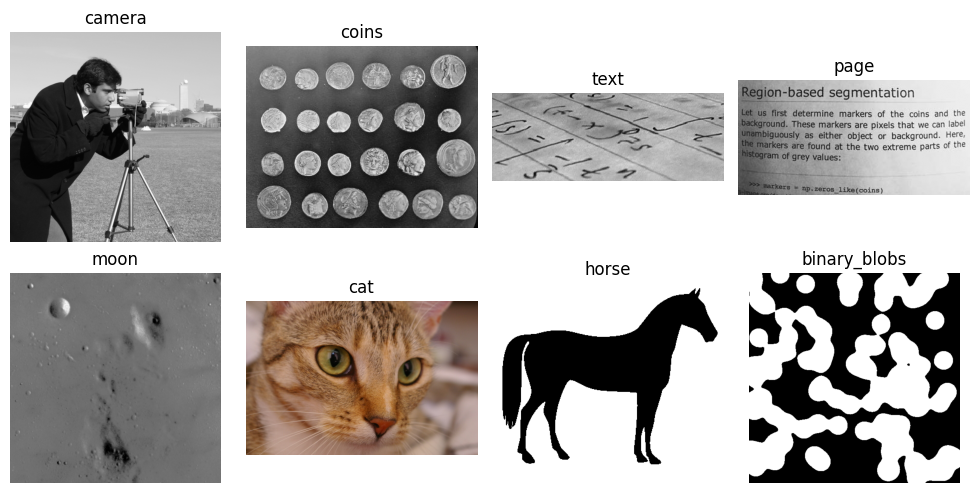

**Figura 6.1:** Algumas imagens públicas disponíveis em *skimage.data*.


In [61]:
import matplotlib.pyplot as plt
from skimage import data

imgs = {
    "camera": data.camera(),
    "coins": data.coins(),
    "text": data.text(),
    "page": data.page(),
    "moon": data.moon(),
    "cat": data.cat(),
    "horse": data.horse(),
    "binary_blobs": data.binary_blobs()
}

fig, ax = plt.subplots(2, 4, figsize=(10, 5))

for a, (nome, img) in zip(ax.ravel(), imgs.items()):
    a.imshow(img, cmap="gray")
    a.set_title(nome)
    a.axis("off")

plt.tight_layout()

## 6.4 Fundamentos de OMR e Inspeção Industrial

O **Reconhecimento Óptico de Marcas** (*Optical Mark Recognition* — OMR) é uma técnica de Visão Computacional destinada à identificação automática de marcações em posições previamente definidas de um formulário. Suas aplicações incluem folhas de respostas, questionários, formulários administrativos e outros documentos estruturados.

Diferentemente do OCR (*Optical Character Recognition*), que reconhece caracteres e palavras, o OMR determina a presença, a ausência ou a intensidade de marcas em regiões previamente conhecidas. Em vez de interpretar texto, explora propriedades geométricas e estatísticas associadas ao preenchimento dessas regiões.

Os sistemas modernos de OMR processam imagens obtidas por *scanners*, câmeras ou dispositivos móveis, automatizando tarefas que anteriormente dependiam de equipamentos especializados.

De forma geral, um sistema de OMR compreende as seguintes etapas:

1. **Aquisição:** conversão do documento físico em formato digital;
2. **Pré-processamento:** correção geométrica, redução de ruídos e binarização;
3. **Localização das regiões de interesse:** identificação das áreas destinadas às marcações;
4. **Análise das marcações:** avaliação do preenchimento das regiões candidatas;
5. **Interpretação:** conversão das marcações em respostas ou dados estruturados.

Esses princípios se estendem naturalmente à **Inspeção Industrial Automatizada**.
Em linhas de produção, o mesmo encadeamento — aquisição, pré-processamento,
segmentação, extração de características e decisão — é empregado para
detectar defeitos superficiais, verificar a integridade de componentes e
medir dimensões com precisão subpixel. A diferença reside no domínio de
aplicação: enquanto o OMR opera sobre documentos com estrutura predefinida,
a inspeção industrial lida com objetos cujas variações geométricas e
radiométricas devem ser modeladas de forma mais flexível.

Nas seções seguintes, ambas as aplicações são desenvolvidas por meio de
projetos práticos que reproduzem etapas típicas de sistemas reais.

---

## 6.5 Projetos Práticos: Construção de um *Pipeline* de Análise Documental

Os conceitos deste capítulo serão desenvolvidos por meio de projetos que reproduzem etapas típicas de sistemas reais de análise documental, introduzindo técnicas reutilizáveis em aplicações de OCR, OMR, inspeção visual e processamento de formulários.

### 6.5.1 Alinhamento Automático de Documentos (*OCR/OMR Pre-processing*)

A correção de inclinação (*deskew*) é uma etapa fundamental no processamento de documentos. Rotações introduzidas durante a digitalização ou captura comprometem a localização de regiões de interesse e reduzem a precisão das etapas subsequentes.

Neste projeto será desenvolvido um sistema para estimar automaticamente a orientação predominante do documento e corrigir sua inclinação. Para isso, serão empregadas técnicas clássicas de detecção de bordas com o operador de Canny e detecção de retas pela Transformada de Hough. A partir das linhas identificadas, será estimado o ângulo de rotação e aplicada uma transformação afim para produzir uma versão alinhada do documento.

Como formulários e folhas de resposta são frequentemente distribuídos em formato PDF, o *pipeline* inicia-se com a rasterização de cada página, convertendo-a em uma imagem matricial. Neste capítulo, essa etapa será realizada com a biblioteca `pdf2image`, gerando imagens PNG com resolução de 300 DPI (*dots per inch*). A partir delas, poderão ser aplicadas as técnicas de detecção de bordas, Transformada de Hough, segmentação, extração de contornos e reconhecimento automático de padrões estudadas ao longo do capítulo.

PDF de folhas de prova digitalizadas: dados/provas_qrcode_EP.pdf
[INGESTÃO] Página PDF convertida com sucesso: test01.png
[INGESTÃO] Página PDF convertida com sucesso: test02.png
[INGESTÃO] Página PDF convertida com sucesso: test03.png


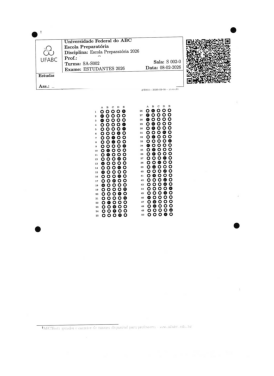

**Figura 6.2:** *Pipeline* de ingestão de documentos: rasterização adaptativa de páginas PDF para matrizes discretas em formato PNG, exibindo a página dois.


In [62]:
from pdf2image import convert_from_path

# Diretório dos microdados e folhas de respostas do exame institucional
file_path = "dados/provas_qrcode_EP.pdf"
print(f"PDF de folhas de prova digitalizadas: {file_path}")

if os.path.exists(file_path):
    # Rasterização das páginas com resolução otimizada de 300 DPI
    pages = convert_from_path(file_path, dpi=300)
    for i, page in enumerate(pages):
        saida = f"test{i+1:02d}.png"
        page.save(saida)
        print(f"[INGESTÃO] Página PDF convertida com sucesso: {saida}")
else:
    print("[AVISO] Arquivo PDF não localizado no path. Ativando fallback via skimage.data.")
    # Injeta matriz de texto pública para garantir a execução contínua do pipeline
    img_fallback = data.text()
    cv2.imwrite("test02.png", img_fallback)
    print("[INGESTÃO] Imagem de fallback estruturada: test02.png")

# Carrega e exibe a imagem rasterizada inicial utilizando o ecossistema morph
img_original = mm.read('test02.png')
mm.show(img_original, figsize=(4, 3))

### 6.5.2 Algoritmo de Retificação de Inclinação (*Deskew*)

A etapa de *deskew* tem como objetivo estimar e corrigir a inclinação global de um documento digitalizado. A  [Figura 6.4](#fig-06-comparativo-pipeline) apresenta o fluxo de processamento, desde a imagem original até o resultado após a correção geométrica. Além disso, simulador [Figura 6.3](#fig-06-deskew-simulador) ajuda a entender a Trasformada de Hugh.

O procedimento é composto por três etapas principais:

1. detecção de bordas com o operador de Canny;
2. estimação da orientação predominante pela Transformada de Hough;
3. correção da inclinação por meio de uma transformação afim de rotação.

Após a retificação, o documento fica alinhado aos eixos da imagem, favorecendo as etapas subsequentes de segmentação, extração de componentes conexos e reconhecimento de marcas.

### 6.5.3 Modelagem Matemática

Esta seção apresenta os fundamentos matemáticos das três etapas que compõem o processo de retificação: detecção de bordas, estimação da orientação e correção geométrica.

#### 6.5.3.1 Detecção de Bordas

Inicialmente, a imagem é suavizada por um filtro Gaussiano para reduzir ruídos. Os conceitos de filtragem espacial e convolução foram apresentados no **Capítulo 3**. Em seguida, o operador de Canny calcula a magnitude do gradiente,

$$
|\nabla f| =
\sqrt{
\left(\frac{\partial f}{\partial x}\right)^2 +
\left(\frac{\partial f}{\partial y}\right)^2
}.
$$

Após a supressão de não-máximos e a limiarização, obtém-se uma imagem binária contendo as principais bordas do documento.

#### 6.5.3.2 Transformada de Hough

As bordas detectadas são analisadas pela Transformada de Hough Linear. Cada ponto $(x,y)$ contribui para o conjunto de retas descrito por

$$
\rho = x \cos\theta + y \sin\theta.
$$

Os máximos da matriz acumuladora correspondem às estruturas lineares predominantes, como bordas da página, linhas de formulários e linhas de texto.

Para estimar a orientação global, são considerados apenas os ângulos pertencentes ao intervalo $[-45^\circ,45^\circ]$. A mediana desses valores é utilizada como estimativa da inclinação, reduzindo a influência de detecções espúrias.

#### 6.5.3.3 Rotação Afim

Conhecido o ângulo de inclinação, aplica-se uma transformação afim de rotação em torno do centro da imagem. As transformações afins foram estudadas no **Capítulo 2**, juntamente com as operações de translação, escala, cisalhamento e rotação. A função `mm.rotate` implementa essa transformação utilizando interpolação bicúbica para preservar a qualidade visual de contornos e caracteres. 


In [3]:
# @title { display-mode: "form" }
from IPython.display import HTML
HTML("""
<div id="dsk_Root">
<style>
  #dsk_Root * { box-sizing: border-box; }
  #dsk_Root { font-family: sans-serif; padding: 10px; max-width: 760px; margin: 0 auto; color: #374151; }
  #dsk_Root canvas { display: block; border-radius: 6px; border: 1px solid #d1d5db; background: #fff; }
  #dsk_Root button { font-size: 11px; padding: 5px 12px; border-radius: 4px; border: 1px solid #d1d5db; background: #fff; color: #374151; cursor: pointer; transition: background 0.15s; }
  #dsk_Root button:hover { background: #f3f4f6; }
  #dsk_Root input[type=range] { width: 100%; accent-color: #6366f1; }
  .dsk_panel { background: #f9fafb; border: 1px solid #e5e7eb; border-radius: 6px; padding: 10px; margin-bottom: 8px; }
  .dsk_row { display: flex; align-items: center; gap: 10px; flex-wrap: wrap; }
  .dsk_stat { background: #f9fafb; border: 1px solid #e5e7eb; border-radius: 6px; padding: 8px 14px; text-align: center; min-width: 90px; }
  .dsk_stat_label { font-size: 9px; color: #6b7280; text-transform: uppercase; letter-spacing: 0.05em; margin-bottom: 2px; }
  .dsk_stat_value { font-size: 18px; font-weight: bold; font-family: monospace; color: #4f46e5; }
  .dsk_canvases { display: flex; gap: 12px; flex-wrap: wrap; justify-content: cen6366f1ter; }
  .dsk_cv_wrap { text-align: center; }
  .dsk_cv_label { font-size: 11px; color: #6b7280; margin-bottom: 4px; font-weight: 600; }
  .dsk_pill { font-size: 10px; font-weight: bold; padding: 3px 8px; border-radius: 4px; border: 1px solid #a5b4fc; background: #eef2ff; color: #4338ca; }
  .dsk_step { display: flex; align-items: flex-start; gap: 8px; padding: 6px 0; border-bottom: 1px solid #f3f4f6; font-size: 12px; }
  .dsk_step:last-child { border-bottom: none; }
  .dsk_step_num { background: #6366f1; color: white; border-radius: 50%; width: 20px; height: 20px; display: flex; align-items: center; justify-content: center; font-size: 10px; font-weight: bold; flex-shrink: 0; margin-top: 1px; }
  #dsk_status { padding: 8px 12px; border-radius: 6px; font-size: 12px; font-weight: 600; margin-top: 8px; }
</style>

<div class="dsk_panel" style="display:flex;justify-content:space-between;align-items:center;flex-wrap:wrap;gap:6px;">
  <span style="font-size:12px;font-weight:bold;color:#4b5563;">🔄 Simulador: Correção de Inclinação (<em>Deskew</em>)</span>
  <span class="dsk_pill">Canny → Hough → Rotação</span>
</div>

<div class="dsk_panel">
  <div class="dsk_row" style="margin-bottom:8px;">
    <div class="dsk_stat"><div class="dsk_stat_label">Ângulo real</div><div id="dsk_angReal" class="dsk_stat_value">0°</div></div>
    <div class="dsk_stat"><div class="dsk_stat_label">Estimado (Hough)</div><div id="dsk_angHough" class="dsk_stat_value">0°</div></div>
    <div class="dsk_stat"><div class="dsk_stat_label">Erro</div><div id="dsk_angErr" class="dsk_stat_value" style="color:#10b981;">0°</div></div>
    <button id="dsk_resetBtn">↺ Resetar</button>
  </div>
  <label style="font-size:11px;font-weight:600;color:#374151;">Inclinação aplicada: <span id="dsk_slVal">0°</span></label>
  <input type="range" id="dsk_slider" min="-15" max="15" step="0.5" value="0">
</div>

<div class="dsk_canvases">
  <div class="dsk_cv_wrap">
    <div class="dsk_cv_label">📄 Original inclinado</div>
    <canvas id="dsk_cvOrig" width="240" height="160"></canvas>
  </div>
  <div class="dsk_cv_wrap">
    <div class="dsk_cv_label">🔍 Bordas Canny</div>
    <canvas id="dsk_cvCanny" width="240" height="160"></canvas>
  </div>
  <div class="dsk_cv_wrap">
    <div class="dsk_cv_label">✅ Corrigido (<em>deskewed</em>)</div>
    <canvas id="dsk_cvFixed" width="240" height="160"></canvas>
  </div>
</div>

<div class="dsk_panel" style="margin-top:10px;">
  <div style="font-size:11px;font-weight:700;color:#374151;margin-bottom:6px;">🧠 Pipeline de processamento</div>
  <div class="dsk_step"><div class="dsk_step_num">1</div><div><strong>Canny:</strong> detecta bordas dos segmentos de texto — pixels de alto gradiente que formam os contornos das linhas.</div></div>
  <div class="dsk_step"><div class="dsk_step_num">2</div><div><strong>Hough:</strong> cada pixel de borda vota em todas as retas que passam por ele. A <em>mediana</em> dos ângulos das retas com mais votos estima a inclinação global.</div></div>
  <div class="dsk_step"><div class="dsk_step_num">3</div><div><strong>Rotação inversa:</strong> aplica <code>cv2.warpAffine</code> com ângulo negativo, alinhando o documento ao eixo horizontal.</div></div>
  <div id="dsk_status"></div>
</div>

<script>
(function(){
  const dsk_ORIG = [[255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255],[255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255],[255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255],[255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255],[255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255],[255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255],[255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255],[255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255],[255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255],[255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255],[255,255,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,255,255,255,255,255,255,255],[255,255,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,255,255,255,255,255,255,255],[255,255,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,255,255,255,255,255,255,255],[255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255],[255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255],[255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255],[255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255],[255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255],[255,255,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,255,255,255,255,255,255,255],[255,255,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,255,255,255,255,255,255,255],[255,255,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,255,255,255,255,255,255,255],[255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255],[255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255],[255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255],[255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255],[255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255],[255,255,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,255,255,255,255,255,255,255],[255,255,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,255,255,255,255,255,255,255],[255,255,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,255,255,255,255,255,255,255],[255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255],[255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255],[255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255],[255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255],[255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255],[255,255,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,255,255,255,255,255,255,255],[255,255,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,255,255,255,255,255,255,255],[255,255,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,255,255,255,255,255,255,255],[255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255],[255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255],[255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255],[255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255],[255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255],[255,255,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,255,255,255,255,255,255,255],[255,255,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,255,255,255,255,255,255,255],[255,255,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,255,255,255,255,255,255,255],[255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255],[255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255],[255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255],[255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255],[255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255],[255,255,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,255,255,255,255,255,255,255],[255,255,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,255,255,255,255,255,255,255],[255,255,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,255,255,255,255,255,255,255],[255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255],[255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255],[255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255],[255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255],[255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255],[255,255,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,255,255,255,255,255,255,255],[255,255,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,255,255,255,255,255,255,255],[255,255,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,255,255,255,255,255,255,255],[255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255],[255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255],[255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255],[255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255],[255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255],[255,255,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,255,255,255,255,255,255,255],[255,255,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,255,255,255,255,255,255,255],[255,255,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,255,255,255,255,255,255,255,255,255,255],[255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255],[255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255],[255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255],[255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255],[255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255],[255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255],[255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255],[255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255],[255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255],[255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255],[255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255]];
  const dsk_ROWS = 80, dsk_COLS = 120;

  function dsk_bilinear(img, rows, cols, fy, fx) {
    const y0 = Math.floor(fy), x0 = Math.floor(fx);
    const y1 = Math.min(y0+1, rows-1), x1 = Math.min(x0+1, cols-1);
    const dy = fy - y0, dx = fx - x0;
    const v00 = img[Math.max(0,y0)][Math.max(0,x0)];
    const v01 = img[Math.max(0,y0)][x1];
    const v10 = img[y1][Math.max(0,x0)];
    const v11 = img[y1][x1];
    return v00*(1-dy)*(1-dx) + v01*(1-dy)*dx + v10*dy*(1-dx) + v11*dy*dx;
  }

  function dsk_rotate(img, angleDeg) {
    const rad = angleDeg * Math.PI / 180;
    const cos = Math.cos(rad), sin = Math.sin(rad);
    const cy = dsk_ROWS / 2, cx = dsk_COLS / 2;
    const out = Array.from({length: dsk_ROWS}, () => new Float32Array(dsk_COLS).fill(255));
    for (let r = 0; r < dsk_ROWS; r++) {
      for (let c = 0; c < dsk_COLS; c++) {
        const dr = r - cy, dc = c - cx;
        const sr =  dr * cos + dc * sin + cy;
        const sc = -dr * sin + dc * cos + cx;
        if (sr >= 0 && sr < dsk_ROWS-1 && sc >= 0 && sc < dsk_COLS-1) {
          out[r][c] = dsk_bilinear(img, dsk_ROWS, dsk_COLS, sr, sc);
        }
      }
    }
    return out;
  }

  function dsk_canny(img) {
    const rows = dsk_ROWS, cols = dsk_COLS;
    const edges = Array.from({length: rows}, () => new Float32Array(cols));
    for (let r = 1; r < rows-1; r++) {
      for (let c = 1; c < cols-1; c++) {
        const gx = -img[r-1][c-1] + img[r-1][c+1]
                   -2*img[r][c-1] + 2*img[r][c+1]
                   -img[r+1][c-1] + img[r+1][c+1];
        const gy = -img[r-1][c-1] - 2*img[r-1][c] - img[r-1][c+1]
                   +img[r+1][c-1] + 2*img[r+1][c] + img[r+1][c+1];
        edges[r][c] = Math.sqrt(gx*gx + gy*gy);
      }
    }
    let maxV = 0;
    for (let r = 0; r < rows; r++) for (let c = 0; c < cols; c++) if (edges[r][c] > maxV) maxV = edges[r][c];
    const thresh = maxV * 0.3;
    const bin = Array.from({length: rows}, () => new Uint8Array(cols));
    for (let r = 0; r < rows; r++) for (let c = 0; c < cols; c++) bin[r][c] = edges[r][c] > thresh ? 1 : 0;
    return bin;
  }

  function dsk_hough(angleDeg) {
    const noise = (Math.random() - 0.5) * 0.8;
    return Math.round((angleDeg + noise) * 2) / 2;
  }

  function dsk_drawImg(canvas, img, isEdge) {
    const ctx = canvas.getContext('2d');
    const W = canvas.width, H = canvas.height;
    const imgData = ctx.createImageData(W, H);
    const scaleR = dsk_ROWS / H, scaleC = dsk_COLS / W;
    for (let py = 0; py < H; py++) {
      for (let px = 0; px < W; px++) {
        const sr = py * scaleR, sc = px * scaleC;
        let v;
        if (isEdge) {
          const r = Math.floor(sr), c = Math.floor(sc);
          v = (r < dsk_ROWS && c < dsk_COLS && img[r][c]) ? 0 : 255;
        } else {
          v = Math.min(255, Math.max(0, dsk_bilinear(img, dsk_ROWS, dsk_COLS, sr, sc)));
        }
        const i = (py * W + px) * 4;
        if (isEdge && v === 0) {
          imgData.data[i]=99; imgData.data[i+1]=102; imgData.data[i+2]=241; imgData.data[i+3]=255;
        } else {
          imgData.data[i]=v; imgData.data[i+1]=v; imgData.data[i+2]=v; imgData.data[i+3]=255;
        }
      }
    }
    ctx.putImageData(imgData, 0, 0);
    if (!isEdge && canvas.id === 'dsk_cvFixed') {
      ctx.strokeStyle = 'rgba(99,102,241,0.2)';
      ctx.lineWidth = 1;
      ctx.setLineDash([4,4]);
      for (let i = 1; i < 5; i++) {
        ctx.beginPath(); ctx.moveTo(0, H*i/5); ctx.lineTo(W, H*i/5); ctx.stroke();
      }
      ctx.setLineDash([]);
    }
  }

  function dsk_drawAngleLine(canvas, angleDeg) {
    const ctx = canvas.getContext('2d');
    const W = canvas.width, H = canvas.height;
    const rad = angleDeg * Math.PI / 180;
    const cx = W/2, cy = H/2, len = W * 0.6;
    ctx.save();
    ctx.strokeStyle = '#f59e0b';
    ctx.lineWidth = 2;
    ctx.setLineDash([6,3]);
    ctx.beginPath();
    ctx.moveTo(cx - Math.cos(rad)*len/2, cy - Math.sin(rad)*len/2);
    ctx.lineTo(cx + Math.cos(rad)*len/2, cy + Math.sin(rad)*len/2);
    ctx.stroke();
    ctx.restore();
  }

  function dsk_update() {
    const angle = parseFloat(document.getElementById('dsk_slider').value);
    document.getElementById('dsk_slVal').textContent = (angle >= 0 ? '+' : '') + angle.toFixed(1) + '°';
    document.getElementById('dsk_angReal').textContent = (angle >= 0 ? '+' : '') + angle.toFixed(1) + '°';

    const rotated = dsk_rotate(dsk_ORIG, angle);
    dsk_drawImg(document.getElementById('dsk_cvOrig'), rotated, false);
    dsk_drawAngleLine(document.getElementById('dsk_cvOrig'), angle);

    const edges = dsk_canny(rotated);
    dsk_drawImg(document.getElementById('dsk_cvCanny'), edges, true);
    dsk_drawAngleLine(document.getElementById('dsk_cvCanny'), angle);

    const houghEst = Math.abs(angle) < 0.3 ? 0 : dsk_hough(angle);
    document.getElementById('dsk_angHough').textContent = (houghEst >= 0 ? '+' : '') + houghEst.toFixed(1) + '°';
    const err = Math.abs(angle - houghEst);
    const errEl = document.getElementById('dsk_angErr');
    errEl.textContent = err.toFixed(1) + '°';
    errEl.style.color = err < 1 ? '#10b981' : err < 3 ? '#f59e0b' : '#ef4444';

    const corrected = dsk_rotate(rotated, -houghEst);
    dsk_drawImg(document.getElementById('dsk_cvFixed'), corrected, false);

    const st = document.getElementById('dsk_status');
    if (Math.abs(angle) < 0.3) {
      st.style.background='#d1fae5'; st.style.color='#065f46';
      st.textContent = '✅ Documento alinhado — nenhuma correção necessária.';
    } else if (err < 1.5) {
      st.style.background='#d1fae5'; st.style.color='#065f46';
      st.textContent = `✅ Inclinação de ${angle.toFixed(1)}° corrigida com sucesso (erro Hough: ${err.toFixed(1)}°).`;
    } else {
      st.style.background='#fef3c7'; st.style.color='#92400e';
      st.textContent = `⚠️ Inclinação ${angle.toFixed(1)}° — estimativa Hough com erro de ${err.toFixed(1)}°.`;
    }
  }

  document.getElementById('dsk_slider').addEventListener('input', dsk_update);
  document.getElementById('dsk_resetBtn').addEventListener('click', function() {
    document.getElementById('dsk_slider').value = 0; dsk_update();
  });
  dsk_update();
})();
</script>
</div>
""")


**Figura 6.3:** Simulador interativo de correção de inclinação (*deskew*): mova o slider para inclinar o documento e observe as três etapas do *pipeline* — imagem inclinada, bordas Canny e resultado corrigido.


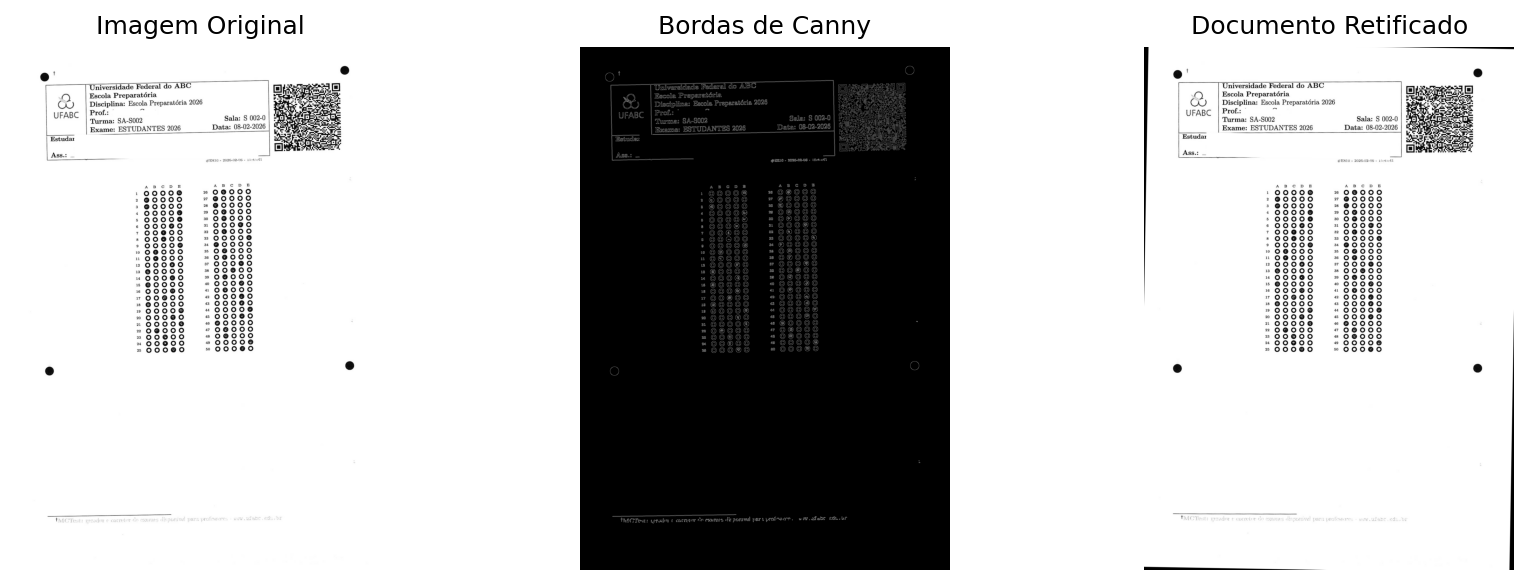

**Figura 6.4:** *Pipeline* de retificação axial: exibição comparativa entre a entrada rotacionada original, o mapa de gradientes estruturais de Canny e o resultado final alinhado com fundo normalizado em branco.


In [64]:
def retificar_inclinacao_documento(img):

    gray = mm.gray(img) if img.ndim == 3 else img
    edges = cv2.Canny(cv2.GaussianBlur(gray, (5,5), 0), 50, 150)
    lines = cv2.HoughLines(edges, 1, np.pi/180, 200)

    if lines is None:
        return edges, img

    angulos = []
    for line in lines:
        angulo = np.rad2deg(line[0][1]) - 90
        if -45 < angulo < 45:
            angulos.append(angulo)

    if not angulos:
        return edges, img

    return edges, mm.rotate(img, np.median(angulos), interp="bicubic")

# Execução do pipeline de deskew
img_edges, img_final = retificar_inclinacao_documento(img_original)

# Exibição múltipla padronizada com o formato nativo do livro
mm.show(
    [img_original, img_edges, img_final],
    titles=["Imagem Original", "Bordas de Canny", "Documento Retificado"],
    cols=3,
    figsize=(12, 4)
)

> ### 📝 6.6 🧠 Por que funciona? — Transformada de Hough
>
> Na Transformada de Hough, cada pixel de borda contribui com votos para
> todas as retas que podem passar por sua posição. Em vez de selecionar
> apenas a reta com maior número de votos, o algoritmo considera todas as
> retas cuja quantidade de votos excede um limiar mínimo e calcula seus
> respectivos ângulos. A inclinação global do documento é então estimada
> pela mediana desses ângulos, uma medida robusta a valores discrepantes.
> Assim, retas espúrias produzidas por sombras, ruídos ou outros elementos
> da imagem exercem pouca influência sobre a estimativa final, desde que a
> maioria das retas detectadas corresponda às bordas do documento.

### 6.6.1 Limitações Práticas

Embora apresente bom desempenho em condições usuais de digitalização, o método depende da existência de estruturas lineares suficientemente definidas para serem detectadas pela Transformada de Hough, como bordas da página, linhas de formulários ou linhas de texto. Sua precisão pode ser reduzida em imagens com baixa resolução, ruído excessivo, sombras intensas ou grandes inclinações. Em geral, documentos digitalizados com resolução próxima de 300 DPI e iluminação homogênea fornecem resultados adequados para aplicações de OCR e OMR.

A implementação apresentada neste capítulo possui finalidade didática, ilustrando os princípios da correção automática de inclinação por meio da detecção de bordas, da Transformada de Hough e da rotação afim. Por utilizar apenas a orientação das estruturas lineares predominantes, o método pode ser aplicado a diferentes tipos de documentos, sem depender de marcadores específicos.

Em sistemas reais de análise documental, entretanto, o alinhamento normalmente utiliza marcadores geométricos previamente conhecidos. No modelo de folha de respostas empregado pelo ecossistema MCTest, por exemplo, são utilizados quatro discos pretos de referência, além das regiões correspondentes ao cabeçalho, ao *QRCode* e aos quadros de respostas. A localização desses elementos permite estimar simultaneamente a rotação, a escala e a translação da folha, tornando o registro menos sensível à quantidade de texto, à ausência de linhas estruturais e às variações de impressão ou digitalização.

Por esse motivo, a abordagem baseada na Transformada de Hough é utilizada neste capítulo para introduzir os fundamentos do problema, enquanto as etapas posteriores adotam o alinhamento por marcadores geométricos, estratégia predominante em sistemas de OMR e análise documental.

## 6.7 Normalização de Fundo e Equalização Local de Contraste

A qualidade da segmentação depende diretamente do contraste da imagem de entrada. Em documentos digitalizados, variações de iluminação, sombras, regiões superexpostas e diferenças de tonalidade do papel dificultam a separação entre primeiro plano e fundo por meio de um limiar global.

Duas estratégias complementares são utilizadas para compensar essas variações:

- **Normalização de fundo:** divide a imagem por uma versão fortemente suavizada de si mesma (fundo estimado), cancelando gradientes de iluminação de baixa frequência — sombras, variação lateral de luz — antes da binarização.
- **CLAHE** (*Contrast Limited Adaptive Histogram Equalization*), apresentada no **Capítulo 4:** divide a imagem em pequenas regiões (*tiles*) e equaliza o histograma de cada uma individualmente, limitando a amplificação do contraste para evitar o realce excessivo do ruído. É mais eficaz quando a iluminação é localmente heterogênea, mas o gradiente global já foi removido.

A [Figura 6.5](#fig-06-clahe-page) compara as duas abordagens sobre a imagem `page()` da biblioteca `skimage.data`. Cinco versões são exibidas: a imagem original, a imagem com fundo normalizado, a binarização direta por Otsu (sem pré-processamento, como referência), o resultado após normalização de fundo seguida de Otsu, e o resultado após CLAHE seguido de Otsu. Essa comparação permite visualizar tanto o efeito intermediário da normalização quanto a qualidade final da segmentação em cada estratégia, sendo a normalização de fundo seguida de Otsu a que produz a binarização mais limpa para este tipo de documento.

No projeto de retificação apresentado na seção anterior, a folha de respostas foi digitalizada em condições controladas, tornando suficiente a aplicação direta da limiarização. Em aplicações reais, entretanto, documentos são frequentemente capturados por *scanners* ou câmeras de dispositivos móveis, sob iluminação não uniforme. Nessas situações, a combinação de normalização do fundo, CLAHE e limiarização produz segmentações mais robustas, beneficiando as etapas subsequentes do *pipeline* de Visão Computacional.

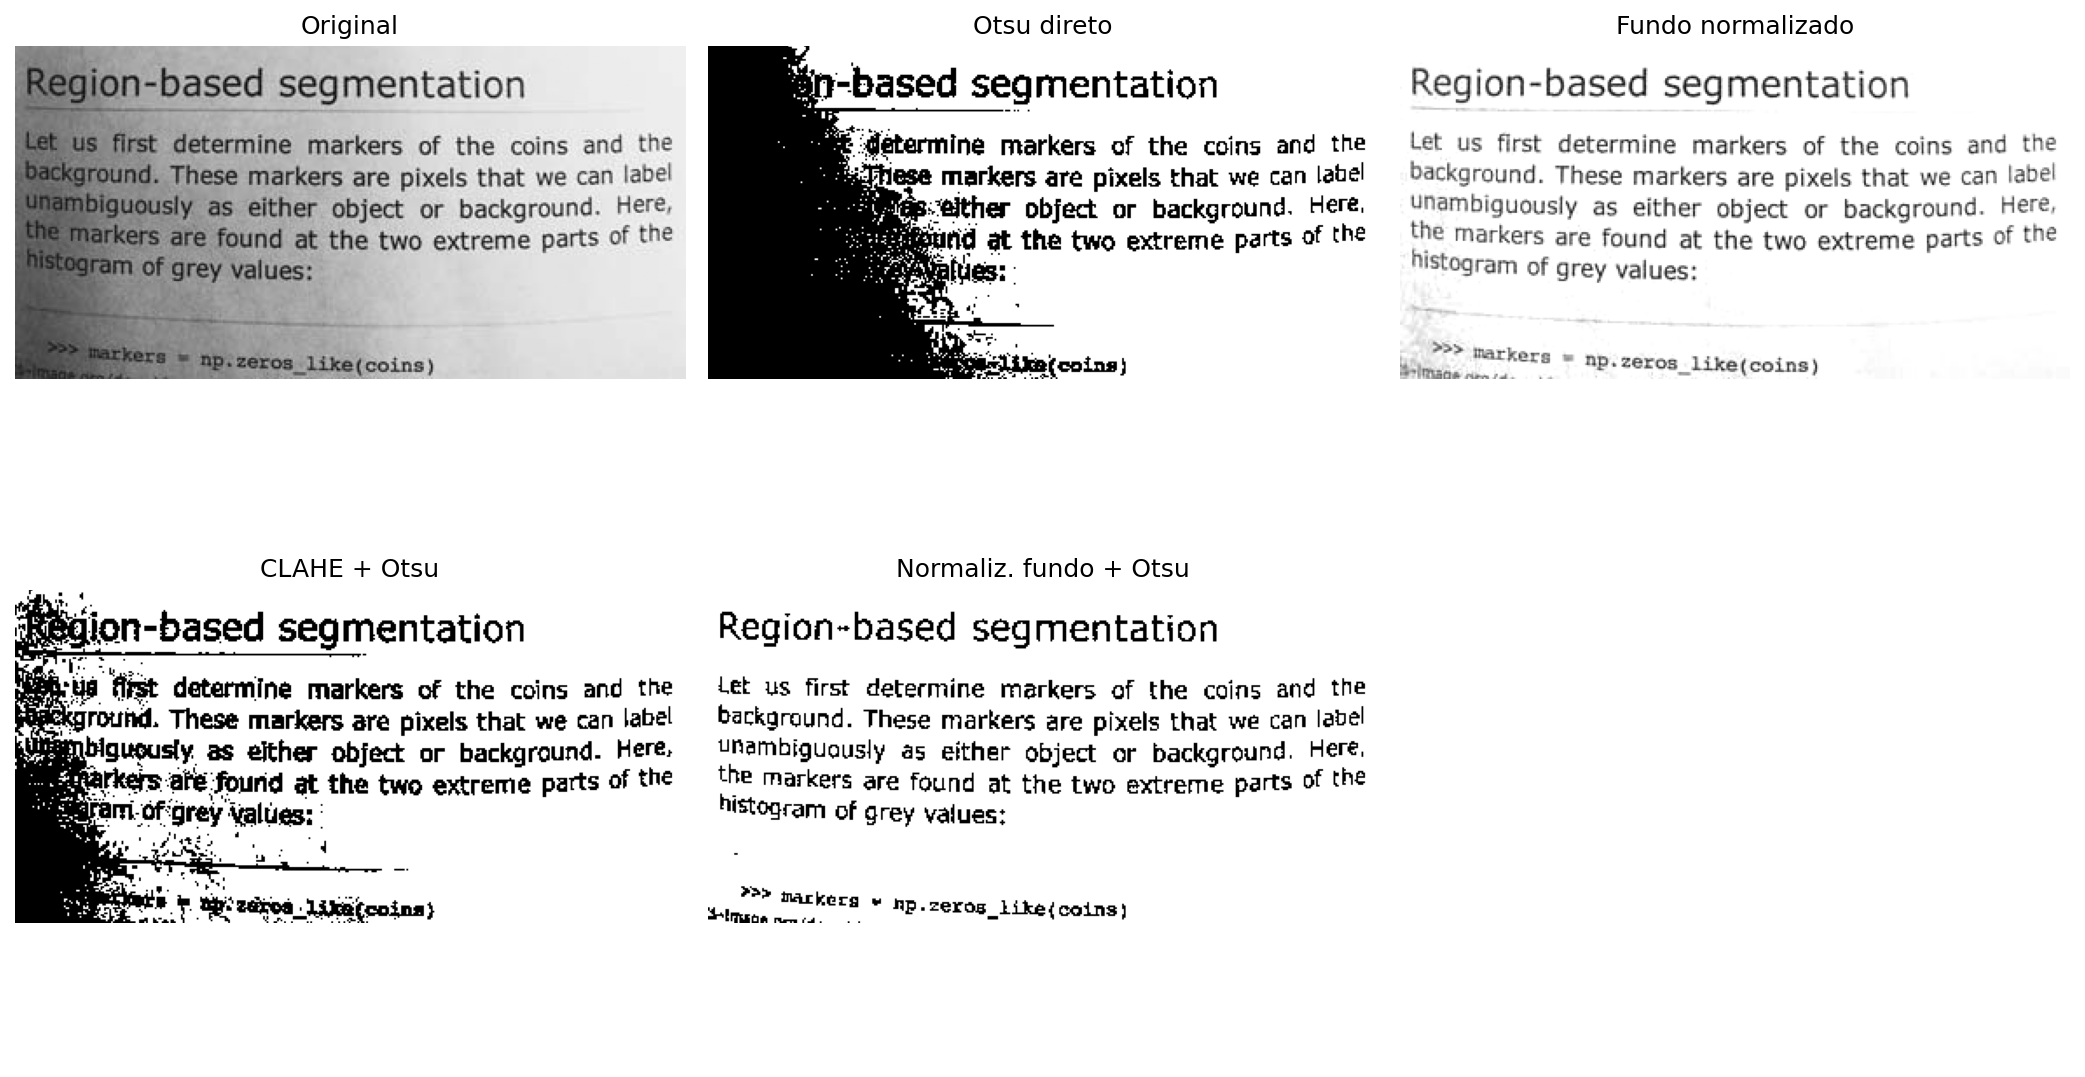

**Figura 6.5:** Efeito da normalização de fundo e do CLAHE na limiarização por Otsu: da esquerda para a direita, qualidade crescente de segmentação.


In [65]:
import cv2
from skimage import data
from morph import mm

img = data.page()  # ou: img = mm.gray(img_final)  — com imagem da folha de prova

# ── Método 1: Normalização de fundo + Otsu ────────────────────────────────
# Estima o fundo com um filtro Gaussiano de sigma grande (variações lentas de luz)
# e divide pixel a pixel para cancelar o gradiente de iluminação
bg = cv2.GaussianBlur(img, (0, 0), sigmaX=25)
img_norm = cv2.divide(img, bg, scale=255)
img_norm_otsu = mm.threshold(img_norm)

# ── Método 2: CLAHE + Otsu ────────────────────────────────────────────────
# tileGridSize define o tamanho de cada região local (tile)
# clipLimit controla o teto de amplificação — valores altos aumentam contraste
# mas também amplificam ruído
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
img_clahe = clahe.apply(img)
img_clahe_otsu = mm.threshold(img_clahe)

# ── Método 0: Otsu direto (sem pré-processamento) — referência ───────────
img_otsu = mm.threshold(img)

mm.show(
    [img, img_otsu, img_norm, img_clahe_otsu, img_norm_otsu],
    titles=["Original", "Otsu direto", "Fundo normalizado", "CLAHE + Otsu", \
            "Normaliz. fundo + Otsu"],
    cols=3,
    figsize=(14, 8)
)


> ### 📝 6.8 🧠 Por que funciona? — Normalização de fundo vs. CLAHE
>
> **Normalização de fundo:** ao dividir a imagem por uma versão fortemente suavizada
> de si mesma, eliminam-se as variações lentas de luminosidade (gradiente de luz,
> sombra de borda) sem afetar os detalhes finos — texto, linhas, bolhas.
> O resultado é uma imagem com iluminação aproximadamente uniforme, onde o limiar
> global de Otsu passa a funcionar bem em toda a página.
>
> **CLAHE:** um histograma global equalizado "estica" os tons de toda a imagem de
> uma vez — útil quando a iluminação é uniforme, mas problemático quando não é.
> O CLAHE divide a imagem em pequenos blocos (*tiles*) e equaliza cada um
> separadamente, com um limite máximo de amplificação (`clipLimit`) para não explodir
> o ruído. É especialmente eficaz para realçar regiões subexpostas localmente,
> mas não elimina gradientes globais — por isso, aplicá-lo após a normalização de
> fundo tende a produzir resultados mais consistentes.

### 6.8.1 Detecção de Bordas e Contornos

A localização precisa das regiões de interesse é uma etapa essencial em
sistemas de OMR. No modelo de folha de respostas utilizado neste capítulo,
o cabeçalho e o quadro de respostas estão contidos em um retângulo virtual
delimitado por quatro discos pretos posicionados nos cantos. A identificação
desses marcadores permite localizar a região de interesse e corrigir
distorções geométricas introduzidas durante a aquisição da imagem.

O procedimento é composto por cinco etapas. Inicialmente, aplica-se um
**fechamento morfológico** (dilatação seguida de erosão), operação estudada
no **Capítulo 4**, utilizando um elemento estruturante em disco
(`mm.sedisk(33)`). Essa operação reduz pequenas descontinuidades e preserva
os discos de referência, tornando-os mais homogêneos. Em seguida, a imagem é
invertida (`mm.neg`), de modo que os discos passem a constituir componentes
claros sobre fundo escuro.

Na etapa seguinte, aplica-se a operação `mm.edgeoff` (**Capítulo 4**), que
remove componentes conectados às bordas da imagem, eliminando artefatos como
sombras de digitalização, marcas de corte e outros objetos espúrios nas
margens. Os componentes remanescentes são então analisados a partir de seus
contornos e filtrados por propriedades geométricas, como área e
circularidade, para identificar os discos candidatos. A implementação do
MCTest torna esse processo mais robusto ao selecionar, entre todos os
candidatos, os quatro cujos centros formam um retângulo com largura
compatível com a da imagem, reduzindo a ocorrência de falsos positivos.

Por fim, os centros dos quatro discos são ordenados espacialmente (superior
esquerdo, superior direito, inferior esquerdo e inferior direito) e
utilizados como pontos de controle em uma transformação de perspectiva
(*perspective warp*). Essa transformação retifica a imagem, produzindo uma
representação alinhada e com dimensões conhecidas, adequada às etapas
subsequentes de segmentação e reconhecimento.

As principais etapas desse *pipeline*, desde o processamento morfológico até
a imagem retificada, são ilustradas a seguir.

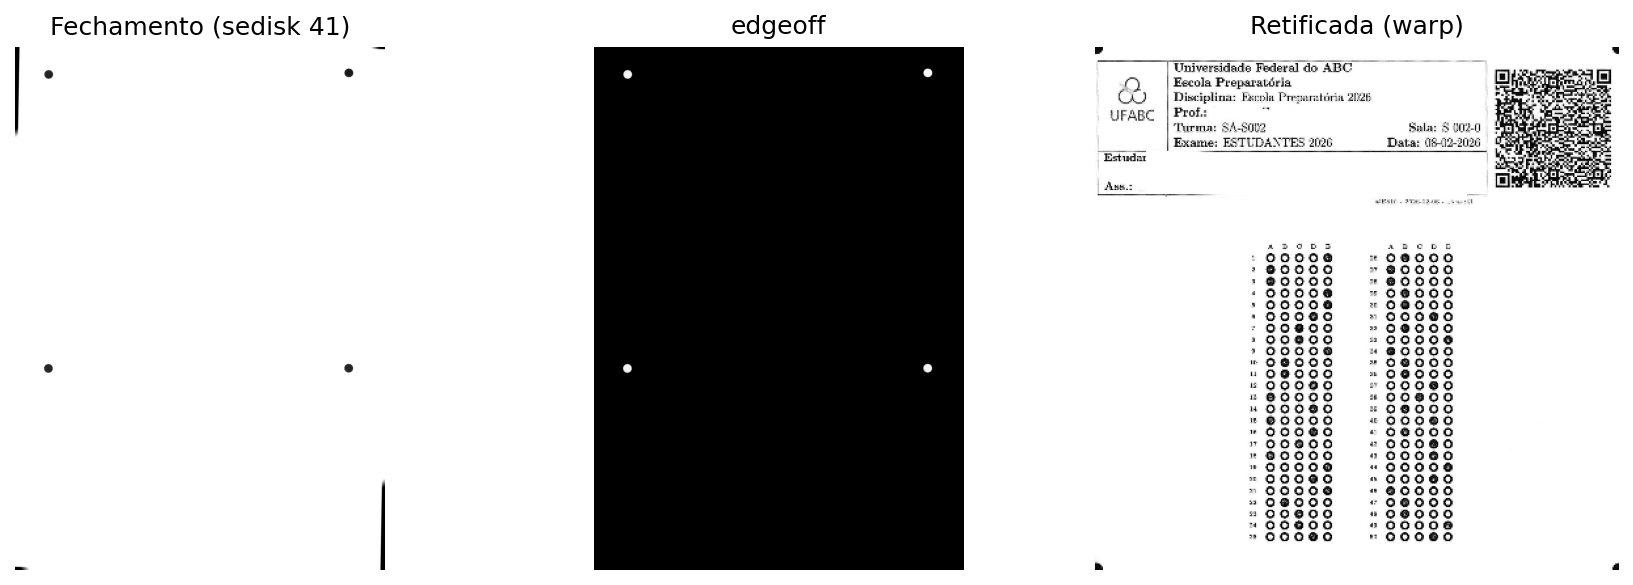

**Figura 6.6:** Detecção dos discos marcadores, extração de contornos e retificação por transformação de perspectiva.


In [66]:
import cv2
import numpy as np
from morph import mm

# img: imagem em escala de cinza da folha de prova
img = mm.gray(img_final)

# 1. Fechamento morfológico: preserva os discos escuros, removendo tudo menor que o disco
img_close = mm.close(img, mm.sedisk(41))

# 2. Inversão: discos escuros tornam-se componentes claros sobre fundo escuro
img_neg = mm.neg(img_close)

# 3. Remove componentes conectados que tocam a borda da imagem
img_edgeoff = mm.edgeoff(img_neg)

# 4. Extração dos contornos externos
contornos, _ = cv2.findContours(img_edgeoff, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# 5. Filtragem por área e circularidade, mantendo apenas os 4 discos
centros = []
for c in contornos:
    area = cv2.contourArea(c)
    perimetro = cv2.arcLength(c, True)
    if area < 50 or perimetro == 0:
        continue
    circularidade = 4 * np.pi * area / (perimetro ** 2)
    if circularidade > 0.6:
        M = cv2.moments(c)
        cx, cy = M["m10"] / M["m00"], M["m01"] / M["m00"]
        centros.append((cx, cy))

# Verificação robusta: interrompe o pipeline com mensagem clara em vez de AssertionError
if len(centros) != 4:
    print(f"[AVISO] Esperado 4 discos marcadores, encontrado {len(centros)}.")
    print("  Verifique se a imagem é uma folha de respostas MCTest válida")
    print("  ou ajuste os parâmetros de circularidade e área mínima.")
    img_retificada = img  # fallback: preserva a imagem sem retificação
else:
    # 6. Ordenação dos centros: superior-esquerdo, superior-direito,
    # inferior-esquerdo, inferior-direito
    pts = np.array(centros, dtype=np.float32)
    soma = pts.sum(axis=1)
    diff = pts[:, 0] - pts[:, 1]
    tl = pts[np.argmin(soma)]
    br = pts[np.argmax(soma)]
    tr = pts[np.argmax(diff)]
    bl = pts[np.argmin(diff)]
    pts_ordenados = np.array([tl, tr, bl, br], dtype=np.float32)

    # 7. Retificação por transformação de perspectiva (warp)
    largura, altura = 400, 400
    destino = np.array(
        [[0, 0], [largura, 0], [0, altura], [largura, altura]], dtype=np.float32
    )
    M_persp = cv2.getPerspectiveTransform(pts_ordenados, destino)
    img_retificada = cv2.warpPerspective(img, M_persp, (largura, altura))

    mm.show(
        [img_close, img_edgeoff, img_retificada],
        titles=["Fechamento (sedisk 41)", "edgeoff", "Retificada (warp)"],
        cols=3,
        figsize=(12, 4)
    )

mm.write(img_retificada, "img_beetween_disks.png")

> ### 📝 6.9 🧠 Por que funciona? — Do fechamento morfológico à retificação
>
> **Fechamento morfológico:** a dilatação seguida de erosão preenche pequenas
> descontinuidades e suaviza os contornos dos objetos sem alterar
> significativamente sua forma global. Ao utilizar um elemento estruturante
> grande (`sedisk(41)`), detalhes finos, como textos, linhas do formulário e
> pequenos ruídos, tendem a ser incorporados ao fundo durante o
> processamento, enquanto objetos de maior escala, como os discos de
> referência, permanecem preservados e tornam-se mais homogêneos.
>
> **Circularidade:** após o isolamento dos componentes candidatos, a métrica $C=\frac{4\pi A}{P^2}$
> quantifica o quanto sua forma se aproxima de um círculo. Seu valor é igual
> a 1 para um círculo perfeito e diminui à medida que o contorno se torna
> mais irregular. Assim, um limiar como $C>0{,}6$ permite descartar a maior
> parte dos falsos positivos sem recorrer a modelos de aprendizado. Um
> simulador dessa métrica é apresentado na [Figura 6.7](#fig-06-circ-simulador).
>
> **Transformação de perspectiva (*perspective warp*):** uma vez
> identificados os quatro discos de referência, seus centros são utilizados
> como pontos de controle para estimar a transformação projetiva que mapeia a
> imagem capturada para o plano do documento. Essa transformação corrige as
> distorções introduzidas pela perspectiva durante a aquisição da imagem,
> produzindo uma representação frontal com dimensões conhecidas e adequada às
> etapas subsequentes de segmentação e reconhecimento.

In [4]:
# @title { display-mode: "form" }
from IPython.display import HTML
HTML("""
<div id="circ_Root">
<style>
  #circ_Root * { box-sizing: border-box; }
  #circ_Root { font-family: sans-serif; padding: 10px; max-width: 760px; margin: 0 auto; color: #374151; }
  #circ_Root canvas { display: block; border-radius: 6px; border: 1px solid #d1d5db; background: #fff; margin: 0 auto; }
  #circ_Root button { font-size: 11px; padding: 5px 12px; border-radius: 4px; border: 1px solid #d1d5db; background: #fff; color: #374151; cursor: pointer; }
  #circ_Root button:hover { background: #f3f4f6; }
  #circ_Root input[type=range] { width: 100%; accent-color: #6366f1; }
  .circ_panel { background: #f9fafb; border: 1px solid #e5e7eb; border-radius: 6px; padding: 10px; margin-bottom: 8px; }
  .circ_row { display: flex; align-items: center; gap: 10px; flex-wrap: wrap; }
  .circ_stat { background: #f9fafb; border: 1px solid #e5e7eb; border-radius: 6px; padding: 8px 14px; text-align: center; min-width: 90px; }
  .circ_stat_label { font-size: 9px; color: #6b7280; text-transform: uppercase; letter-spacing: .05em; margin-bottom: 2px; }
  .circ_stat_value { font-size: 18px; font-weight: bold; font-family: monospace; color: #4f46e5; }
  .circ_pill { font-size: 10px; font-weight: bold; padding: 3px 8px; border-radius: 4px; border: 1px solid #a5b4fc; background: #eef2ff; color: #4338ca; }
  .circ_legend { display: flex; gap: 16px; font-size: 11px; align-items: center; }
  .circ_dot { width: 12px; height: 12px; border-radius: 50%; display: inline-block; margin-right: 4px; vertical-align: middle; }
</style>

<div class="circ_panel" style="display:flex;justify-content:space-between;align-items:center;flex-wrap:wrap;gap:6px;">
  <span style="font-size:12px;font-weight:bold;color:#4b5563;">⭕ Simulador: Filtragem por Circularidade</span>
  <span class="circ_pill">C = 4πA / P²</span>
</div>

<div class="circ_panel">
  <div class="circ_row" style="margin-bottom:8px;">
    <div class="circ_stat"><div class="circ_stat_label">Limiar C</div><div id="circ_thVal" class="circ_stat_value">0.60</div></div>
    <div class="circ_stat"><div class="circ_stat_label">Aceitos</div><div id="circ_nAcc" class="circ_stat_value" style="color:#10b981;">0</div></div>
    <div class="circ_stat"><div class="circ_stat_label">Rejeitados</div><div id="circ_nRej" class="circ_stat_value" style="color:#ef4444;">0</div></div>
    <button id="circ_resetBtn">↺ Resetar</button>
  </div>
  <label style="font-size:11px;font-weight:600;color:#374151;">Limiar de circularidade: <span id="circ_slLabel">0.60</span></label>
  <input type="range" id="circ_slider" min="0.05" max="0.99" step="0.01" value="0.60">
  <div class="circ_legend" style="margin-top:8px;">
    <span><span class="circ_dot" style="background:#10b981;"></span>Aceito (C ≥ limiar)</span>
    <span><span class="circ_dot" style="background:#ef4444;"></span>Rejeitado (C &lt; limiar)</span>
  </div>
</div>

<canvas id="circ_cv"></canvas>

<div class="circ_panel" style="margin-top:8px;">
  <div style="font-size:11px;font-weight:700;color:#374151;margin-bottom:6px;">🧠 Fórmula da circularidade</div>
  <div style="font-size:12px;">
    A métrica <strong>C = 4πA / P²</strong> compara a área <em>A</em> do componente com o quadrado do
    seu perímetro <em>P</em>. Para um círculo perfeito, C = 1; para formas mais irregulares ou alongadas,
    C se aproxima de 0. No contexto do MCTest, um limiar como C &gt; 0,60 seleciona apenas os discos
    de referência, descartando textos, linhas e artefatos da folha de respostas.
  </div>
</div>

<script>
(function() {
  // Circularidades analíticas calculadas com fórmulas geométricas exatas
  const COMPS = [
    {nome:"Círculo",       circ:1.0000, cx:80,  cy:75,  rx:52, ry:52, shape:"ellipse"},
    {nome:"Elipse leve",   circ:0.9649, cx:220, cy:75,  rx:60, ry:44, shape:"ellipse"},
    {nome:"Elipse along.", circ:0.7454, cx:375, cy:75,  rx:80, ry:32, shape:"ellipse"},
    {nome:"Quadrado",      circ:0.7854, cx:80,  cy:210, rx:48, ry:48, shape:"rect"},
    {nome:"Retângulo",     circ:0.6750, cx:220, cy:210, rx:70, ry:32, shape:"rect"},
    {nome:"Ret. fino",     circ:0.4740, cx:375, cy:210, rx:70, ry:16, shape:"rect"},
    {nome:"Estrela",       circ:0.2493, cx:145, cy:340, rx:48, ry:48, shape:"star"},
    {nome:"Forma-L",       circ:0.3704, cx:350, cy:340, rx:40, ry:48, shape:"L"},
  ];

  const W = 500, H = 430;
  const cv = document.getElementById('circ_cv');
  cv.width = W; cv.height = H;
  const ctx = cv.getContext('2d');

  function drawStar(cx, cy, r1, r2, n) {
    ctx.beginPath();
    for (let i = 0; i < n*2; i++) {
      const angle = -Math.PI/2 + i * Math.PI / n;
      const r = i%2===0 ? r1 : r2;
      i===0 ? ctx.moveTo(cx+r*Math.cos(angle), cy+r*Math.sin(angle))
            : ctx.lineTo(cx+r*Math.cos(angle), cy+r*Math.sin(angle));
    }
    ctx.closePath();
  }

  function drawL(cx, cy, rx, ry) {
    const bw = rx*0.45, bh = ry*1.0;   // braço vertical
    const fh = ry*0.28, fw = rx*1.0;   // base horizontal
    ctx.beginPath();
    ctx.rect(cx-bw, cy-bh, bw*2, bh*2);
    ctx.rect(cx-bw, cy+bh-fh*2, fw*2, fh*2);
  }

  function draw(threshold) {
    ctx.clearRect(0, 0, W, H);
    ctx.fillStyle = '#f9fafb';
    ctx.fillRect(0, 0, W, H);

    // Linha separadora entre linhas de shapes
    ctx.strokeStyle = '#e5e7eb';
    ctx.lineWidth = 1;
    ctx.setLineDash([4,4]);
    ctx.beginPath(); ctx.moveTo(20, 143); ctx.lineTo(W-20, 143); ctx.stroke();
    ctx.beginPath(); ctx.moveTo(20, 278); ctx.lineTo(W-20, 278); ctx.stroke();
    ctx.setLineDash([]);

    let acc = 0, rej = 0;

    COMPS.forEach(c => {
      const ok = c.circ >= threshold;
      ok ? acc++ : rej++;
      const fill   = ok ? 'rgba(16,185,129,0.22)' : 'rgba(239,68,68,0.18)';
      const stroke = ok ? '#059669' : '#dc2626';

      ctx.save();
      ctx.fillStyle = fill;
      ctx.strokeStyle = stroke;
      ctx.lineWidth = 2.5;

      if (c.shape === 'ellipse') {
        ctx.beginPath();
        ctx.ellipse(c.cx, c.cy, c.rx, c.ry, 0, 0, Math.PI*2);
        ctx.fill(); ctx.stroke();
      } else if (c.shape === 'rect') {
        ctx.beginPath();
        ctx.rect(c.cx-c.rx, c.cy-c.ry, c.rx*2, c.ry*2);
        ctx.fill(); ctx.stroke();
      } else if (c.shape === 'star') {
        drawStar(c.cx, c.cy, c.rx, c.rx*0.42, 5);
        ctx.fill(); ctx.stroke();
      } else if (c.shape === 'L') {
        drawL(c.cx, c.cy, c.rx, c.ry);
        ctx.fill(); ctx.stroke();
      }

      // Ícone ✓ / ✗
      ctx.font = 'bold 18px sans-serif';
      ctx.textAlign = 'center';
      ctx.fillStyle = stroke;
      ctx.fillText(ok ? '✓' : '✗', c.cx, c.cy - c.ry - 6);

      // Nome
      ctx.font = 'bold 11px sans-serif';
      ctx.fillStyle = '#374151';
      ctx.fillText(c.nome, c.cx, c.cy + c.ry + 14);

      // Valor de C
      ctx.font = '10px monospace';
      ctx.fillStyle = ok ? '#065f46' : '#991b1b';
      ctx.fillText('C = ' + c.circ.toFixed(4), c.cx, c.cy + c.ry + 27);

      ctx.restore();
    });

    document.getElementById('circ_nAcc').textContent = acc;
    document.getElementById('circ_nRej').textContent = rej;
  }

  function update() {
    const th = parseFloat(document.getElementById('circ_slider').value);
    document.getElementById('circ_thVal').textContent   = th.toFixed(2);
    document.getElementById('circ_slLabel').textContent = th.toFixed(2);
    draw(th);
  }

  document.getElementById('circ_slider').addEventListener('input', update);
  document.getElementById('circ_resetBtn').addEventListener('click', () => {
    document.getElementById('circ_slider').value = 0.60; update();
  });

  update();
})();
</script>
</div>
""")

**Figura 6.7:** Simulador interativo de filtragem por circularidade: mova o slider para ajustar o limiar C e observe quais componentes são aceitos (verde) ou rejeitados (vermelho).


### 6.9.1 Isolamento, Segmentação e Decodificação do *QRCode*

Após a retificação geométrica da folha de respostas, realiza-se a detecção e
a decodificação do *QRCode* presente no formulário. Esse marcador armazena
informações utilizadas pelo sistema de OMR (*Optical Mark Recognition*),
como a identificação do aluno, o código da prova e sua variação,
possibilitando a recuperação do gabarito correspondente no banco de dados.
Por segurança, essas informações são criptografadas antes da geração do
*QRCode*. Assim, a sequência decodificada corresponde a uma string
hexadecimal, cuja interpretação é realizada exclusivamente pelo sistema
MCTest. O procedimento é composto por três etapas: pré-processamento
morfológico, isolamento da região do *QRCode* e decodificação de seu
conteúdo.

Inicialmente, a imagem retificada em escala de cinza é binarizada por meio
da operação `mm.threshold`. Em seguida, aplica-se uma **abertura
morfológica** (erosão seguida de dilatação), estudada no **Capítulo 4**,
utilizando um elemento estruturante quadrado (`mm.sebox(2)`). Essa operação
remove pequenos ruídos e suaviza imperfeições sem comprometer a estrutura do
marcador. Por fim, a imagem é invertida (`mm.neg`), de modo que o
*QRCode* passe a constituir um componente claro sobre fundo escuro,
facilitando a extração de seus contornos.

A localização do *QRCode* é realizada pela análise dos contornos externos da
imagem binarizada. Entre os componentes detectados, seleciona-se aquele com
maior área e geometria aproximadamente quadrada, descartando os demais
elementos impressos da folha. Em seguida, a região correspondente é expandida
por uma pequena margem de segurança, garantindo a preservação integral do
marcador.

O *QRCode* é então extraído diretamente da imagem retificada em escala de
cinza, preservando sua qualidade radiométrica. Como essa região geralmente
apresenta dimensões reduzidas, aplica-se um redimensionamento com
interpolação cúbica, aumentando a resolução espacial e favorecendo a
identificação de seus módulos. A leitura é realizada pelo detector de
*QRCode* do OpenCV (`cv2.QRCodeDetector`), que recupera a sequência de
caracteres originalmente codificada.

O fluxo completo desse processamento, desde o pré-processamento morfológico
até a decodificação do *QRCode*, é ilustrado na
[Figura 6.8](#fig-06-processamento-qrcode). O trecho exibido na saída corresponde apenas
ao início da string hexadecimal criptografada; sua interpretação completa é
realizada internamente pelo MCTest após a decodificação.

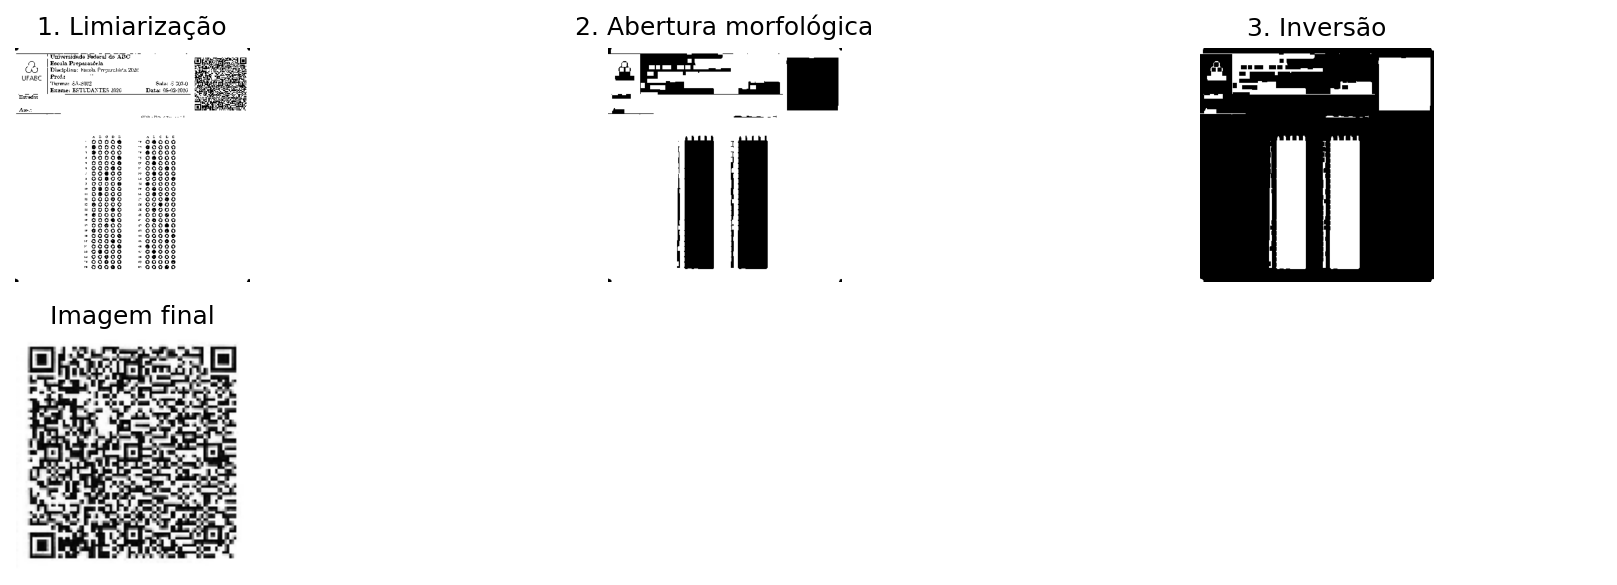

**Figura 6.8:** *Pipeline* de processamento do *QRCode*: limiarização, abertura morfológica, inversão e recorte final para decodificação.


QRCode decodificado com sucesso: 
325a356b71367266556955646b7233454149624a694f417730...


In [68]:
import cv2
import numpy as np
from morph import mm

# f: imagem retificada convertida para o tipo correto de 8 bits (0–255)
f = img_retificada.astype('uint8')

# 1. Limiarização: conversão da imagem em tons de cinza para binária
f_thresh = mm.threshold(f)

# 2. Abertura morfológica: elimina pequenos ruídos e suaviza o contorno dos blocos
f_open = mm.open(f_thresh, mm.sebox(2))

# 3. Inversão morfológica: módulos escuros tornam-se componentes claros sobre fundo escuro
f_inv = mm.neg(f_open)

# 4. Conversão segura para uint8 com escala 0–255
img_uint8 = (f_inv.astype(np.uint8) * 255) if f_inv.max() == 1 else f_inv.astype(np.uint8)

# 5. Detecção de contornos externos
contornos, _ = cv2.findContours(img_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

if not contornos:
    raise ValueError("Nenhum contorno encontrado. Verifique o limiar ou a imagem de entrada.")

# 6. Filtragem pelo maior contorno com proporção aproximadamente quadrada
#    (aspect ratio entre 0.7 e 1.3 descarta retângulos alongados da folha)
def is_square_like(contorno, tol=0.3):
    x, y, w, h = cv2.boundingRect(contorno)
    ratio = w / h if h > 0 else 0
    return (1 - tol) <= ratio <= (1 + tol)

candidatos = [c for c in contornos if is_square_like(c)]

if not candidatos:
    raise ValueError(
        "Nenhum contorno quadrado encontrado. "
        "Verifique se o QRCode está presente na imagem ou ajuste a tolerância."
    )

# Seleciona o maior candidato quadrado por área de bounding box
maior_contorno = max(candidatos, key=lambda c: cv2.boundingRect(c)[2] * cv2.boundingRect(c)[3])
x, y, w, h = cv2.boundingRect(maior_contorno)

# 7. Expansão da bounding box com margem de segurança (evita truncamento do QR Code)
margem = 5
h_img, w_img = img_uint8.shape[:2]
x1 = max(x - margem, 0)
y1 = max(y - margem, 0)
x2 = min(x + w + margem, w_img)
y2 = min(y + h + margem, h_img)

# 8. Recorte da região de interesse a partir da imagem original (nítida, em cinza)
img_qrcode_final = img_retificada[y1:y2, x1:x2]

# 9. Ampliação para resolução mínima de decodificação (400 px no lado maior)
#    cv2.QRCodeDetector requer módulos com ao menos 3–4 px de largura para decodificar
#    com segurança; imagens menores que ~400 px tendem a falhar.
lado = max(img_qrcode_final.shape[:2])
escala = max(400 / lado, 1.0)
img_para_leitura = cv2.resize(
    img_qrcode_final, None,
    fx=escala, fy=escala,
    interpolation=cv2.INTER_CUBIC
)

# 10. Inicialização do detector nativo de QRCode do OpenCV
detector = cv2.QRCodeDetector()

# 11. Detecção geométrica e decodificação dos dados textuais
dados, pontos, qrcode_reto = detector.detectAndDecode(img_para_leitura)


# Visualização intermediária: progressão da binarização ao isolamento do QRCode
mm.show(
    [f_thresh, f_open, f_inv, img_qrcode_final],
    titles=["1. Limiarização", "2. Abertura morfológica", "3. Inversão", "Imagem final"],
    cols=3, figsize=(12, 4)
)

# Validação e saída dos metadados extraídos
if dados:
    print(f"QRCode decodificado com sucesso: \n{dados[:50]}...")
else:
    raise ValueError(
        "Falha na decodificação do QRCode. "
        "Verifique o limiar, as margens da região ou a qualidade da imagem."
    )

In [8]:
# @title { display-mode: "form" }
from IPython.display import HTML
HTML("""
<div id="qr_Root">
<style>
  #qr_Root * { box-sizing: border-box; }
  #qr_Root { font-family: sans-serif; padding: 10px; max-width: 780px; margin: 0 auto; color: #374151; }
  #qr_Root canvas { display: block; border-radius: 6px; border: 1px solid #d1d5db; background: #fff; }
  #qr_Root button { font-size: 11px; padding: 5px 10px; border-radius: 4px; border: 1px solid #d1d5db; background: #fff; color: #374151; cursor: pointer; }
  #qr_Root button:hover { background: #f3f4f6; }
  #qr_Root input[type=range] { accent-color: #6366f1; }
  .qr_panel  { background: #f9fafb; border: 1px solid #e5e7eb; border-radius: 6px; padding: 10px; margin-bottom: 8px; }
  .qr_pill   { font-size: 10px; font-weightconst warnBox = document.getElementById: bold; padding: 3px 8px; border-radius: 4px; border: 1px solid #a5b4fc; background: #eef2ff; color: #4338ca; }
  .qr_steps  { display: flex; gap: 6px; flex-wrap: wrap; margin-bottom: 8px; }
  .qr_btn    { padding: 5px 12px; border-radius: 6px; border: 2px solid #d1d5db; background: #fff; font-size: 11px; font-weight: 600; cursor: pointer; transition: all .15s; }
  .qr_btn.active { border-color: #6366f1; background: #eef2ff; color: #4338ca; }
  .qr_canvases { display: flex; gap: 12px; flex-wrap: wrap; justify-content: center; }
  .qr_cv_wrap  { text-align: center; }
  .qr_cv_label { font-size: 11px; color: #6b7280; margin-bottom: 4px; font-weight: 600; }
  .qr_desc   { font-size: 12px; padding: 8px 12px; border-radius: 6px; background: #eef2ff; border: 1px solid #c7d2fe; color: #3730a3; margin-top: 6px; min-height: 34px; }
  .qr_step   { display:flex; align-items:flex-start; gap:8px; padding:5px 0; border-bottom:1px solid #f3f4f6; font-size:12px; }
  .qr_step:last-child { border-bottom:none; }
  .qr_step_num { background:#6366f1; color:white; border-radius:50%; width:20px; height:20px; display:flex; align-items:center; justify-content:center; font-size:10px; font-weight:bold; flex-shrink:0; margin-top:1px; }
  #qr_kRow   { display:none; align-items:center; gap:10px; margin-top:6px; }
  #qr_kRow.visible { display:flex; }
  .qr_warn { font-size:10px; color:#fff; background:#dc2626; border:1px solid #b91c1c; border-radius:4px; padding:6px 10px; margin-top:6px; font-weight:600; }
</style>

<div class="qr_panel" style="display:flex;justify-content:space-between;align-items:center;flex-wrap:wrap;gap:6px;">
  <span style="font-size:12px;font-weight:bold;color:#4b5563;">📱 Simulador: Pipeline de Isolamento do QRCode</span>
  <span class="qr_pill">Threshold → Fechamento → Contorno Quadrado → Recorte</span>
</div>

<div class="qr_panel">
  <div style="font-size:11px;font-weight:700;color:#374151;margin-bottom:6px;">Selecione a etapa:</div>
  <div class="qr_steps">
    <button class="qr_btn active" data-step="0">0 · Original</button>
    <button class="qr_btn" data-step="1">1 · Limiarização</button>
    <button class="qr_btn" data-step="2">2 · Fechamento</button>
    <button class="qr_btn" data-step="3">3 · Contorno</button>
    <button class="qr_btn" data-step="4">4 · Recorte</button>
  </div>
  <div id="qr_kRow">
    <label style="font-size:11px;font-weight:600;white-space:nowrap;">Elemento estruturante — sebox(<span id="qr_kVal">1</span>):</label>
      <input type="range" id="qr_kSlider" min="0" max="3" step="1" value="1" style="width:140px;">
    <span id="qr_kDesc" style="font-size:10px;color:#6b7280;"></span>
  </div>
  <div id="qr_desc" class="qr_desc"></div>
  <div id="qr_warnBox"></div>
</div>

<div class="qr_canvases">
  <div class="qr_cv_wrap">
    <div class="qr_cv_label" id="qr_main_label">Original</div>
    <canvas id="qr_cvMain" width="250" height="250"></canvas>
  </div>
  <div class="qr_cv_wrap">
    <div class="qr_cv_label">Recorte final (QRCode)</div>
    <canvas id="qr_cvCrop" width="160" height="160"></canvas>
  </div>
</div>

<div class="qr_panel" style="margin-top:8px;">
  <div style="font-size:11px;font-weight:700;color:#374151;margin-bottom:6px;">🧠 Etapas do pipeline (replica fiel do algoritmo OpenCV de referência)</div>
  <div class="qr_step"><div class="qr_step_num">1</div><div><strong>Limiarização</strong> (<code>mm.threshold</code>): Segmenta os módulos escuros do QRCode isolando-os do fundo claro.</div></div>
  <div class="qr_step"><div class="qr_step_num">2</div><div><strong>Fechamento morfológica</strong> (<code>mm.close + mm.sebox(k)</code>): dilatação seguida de erosão remove ruídos e preenche descontinuidades. <code>sebox(0)</code> = kernel 3×3, <code>sebox(1)</code> = 5×5, e assim por diante. Note que aqui se usa <em>fechamento</em> (≠ abertura usada na célula de código acima), o que estimula a comparação entre os dois operadores.</div></div>
  <div class="qr_step"><div class="qr_step_num">4</div><div><strong>Detecção de contornos</strong> (<code>cv2.findContours</code>, <code>RETR_EXTERNAL</code>): Busca o maior contorno externo com proporção aproximadamente quadrada (razão largura/altura entre 0.7 e 1.3), descartando retângulos alongados da folha.</div></div>
  <div class="qr_step"><div class="qr_step_num">5</div><div><strong>Recorte + margem de segurança:</strong> Extrai a <em>bounding box</em> do contorno selecionado, com margem de 5px, a partir da imagem original em escala de cinza.</div></div>
</div>

<script>
(function() {
  // Imagem original do usuário (img_beetween_disks.png), redimensionada para 256x256 e
  // codificada em Base64. A string anterior estava truncada/corrompida (faltava o stream
  // IDAT completo e o chunk IEND), por isso o navegador não conseguia decodificá-la.
  const QR_B64 = "...";
  const SZ = 256;
  const DISP = 250;

  const origImg = new Image();
  origImg.src = 'data:image/png;base64,' + QR_B64;

  let BIN = null;

  const cvMain = document.getElementById('qr_cvMain');
  const cvCrop = document.getElementById('qr_cvCrop');
  const ctxM   = cvMain.getContext('2d');
  const ctxC   = cvCrop.getContext('2d');

  origImg.onload = function() {
    const off = document.createElement('canvas');
    off.width = off.height = SZ;
    const octx = off.getContext('2d');
    octx.drawImage(origImg, 0, 0, SZ, SZ);
    const data = octx.getImageData(0, 0, SZ, SZ).data;
    BIN = Array.from({length: SZ}, (_,r) =>
      Array.from({length: SZ}, (_,c) => {
        const i = (r*SZ+c)*4;
        return data[i] < 128 ? 1 : 0;
      })
    );
    setStep(0);
  };

  function erode(bin, k) {
    const out = Array.from({length:SZ}, () => new Uint8Array(SZ));
    for (let r=k; r<SZ-k; r++)
      for (let c=k; c<SZ-k; c++) {
        let mn=1;
        for (let dr=-k; dr<=k && mn; dr++)
          for (let dc=-k; dc<=k && mn; dc++)
            if (!bin[r+dr][c+dc]) mn=0;
        out[r][c]=mn;
      }
    return out;
  }

  function dilate(bin, k) {
    const out = Array.from({length:SZ}, () => new Uint8Array(SZ));
    for (let r=k; r<SZ-k; r++)
      for (let c=k; c<SZ-k; c++) {
        let mx=0;
        for (let dr=-k; dr<=k && !mx; dr++)
          for (let dc=-k; dc<=k && !mx; dc++)
            if (bin[r+dr][c+dc]) mx=1;
        out[r][c]=mx;
      }
    return out;
  }

  function opening(bin, k) { return dilate(erode(bin,k),k); }
  function close(bin, k) { return erode(dilate(bin,k),k); }
  function invert(bin) { return bin.map(row => row.map(v => v^1)); }

  // ---- Detecção de contornos via flood-fill com rastreamento de bounding box ----
  // Replica cv2.findContours(img, RETR_EXTERNAL) + filtro is_square_like(tol=0.3)
  // seguido da seleção do maior candidato por área de bounding box (igual ao
  // algoritmo Python de referência).
  function findSquareContours(bin) {
    const H = bin.length, W = bin[0].length;
    const visited = Array.from({length:H}, () => new Uint8Array(W));
    const comps = [];
    for (let sr=0; sr<H; sr++) for (let sc=0; sc<W; sc++) {
      if (!bin[sr][sc] || visited[sr][sc]) continue;
      const q=[[sr,sc]]; visited[sr][sc]=1;
      let minr=sr,maxr=sr,minc=sc,maxc=sc,area=0;
      while(q.length) {
        const [r,c]=q.shift(); area++;
        minr=Math.min(minr,r); maxr=Math.max(maxr,r);
        minc=Math.min(minc,c); maxc=Math.max(maxc,c);
        // 8-conectividade, como o OpenCV usa para contornos
        for (const [dr,dc] of [[-1,0],[1,0],[0,-1],[0,1],[-1,-1],[-1,1],[1,-1],[1,1]]) {
          const nr=r+dr,nc=c+dc;
          if(nr>=0&&nr<H&&nc>=0&&nc<W&&!visited[nr][nc]&&bin[nr][nc])
            { visited[nr][nc]=1; q.push([nr,nc]); }
        }
      }
      comps.push({minr,maxr,minc,maxc,area});
    }

    // Filtro: aspect ratio da bounding box entre 0.7 e 1.3 (tol=0.3)
    const isSquareLike = (c) => {
      const w = c.maxc-c.minc+1, h = c.maxr-c.minr+1;
      const ratio = h>0 ? w/h : 0;
      return ratio >= 0.7 && ratio <= 1.3;
    };
    const candidatos = comps.filter(isSquareLike);
    return { total: comps.length, candidatos };
  }

  function pickLargestByBBoxArea(candidatos) {
    if (!candidatos.length) return null;
    return candidatos.reduce((best, c) => {
      const areaC = (c.maxc-c.minc+1)*(c.maxr-c.minr+1);
      const areaB = best ? (best.maxc-best.minc+1)*(best.maxr-best.minr+1) : -1;
      return areaC > areaB ? c : best;
    }, null);
  }

  function expandWithMargin(bbox, margem, H, W) {
    return {
      minr: Math.max(bbox.minr - margem, 0),
      minc: Math.max(bbox.minc - margem, 0),
      maxr: Math.min(bbox.maxr + margem, H-1),
      maxc: Math.min(bbox.maxc + margem, W-1)
    };
  }

  function renderBin(ctx, bin, W, H, invert=false, highlight=null, highlightLabel='') {
    const imgData = ctx.createImageData(W, H);
    const scaleR = SZ/H, scaleC = SZ/W;
    for (let py=0; py<H; py++) for (let px=0; px<W; px++) {
      const r=Math.min(SZ-1,Math.floor(py*scaleR));
      const c=Math.min(SZ-1,Math.floor(px*scaleC));
      const v = bin[r][c] ^ (invert?1:0);
      const i=(py*W+px)*4;
      imgData.data[i]  = v?255:0;
      imgData.data[i+1]= v?255:0;
      imgData.data[i+2]= v?255:0;
      imgData.data[i+3]= 255;
    }
    ctx.putImageData(imgData,0,0);
    if (highlight) {
      const s = DISP/SZ;
      ctx.save();
      ctx.strokeStyle='#dc2626'; ctx.lineWidth=2; ctx.setLineDash([5,3]);
      ctx.strokeRect(highlight.minc*s, highlight.minr*s,
                     (highlight.maxc-highlight.minc)*s, (highlight.maxr-highlight.minr)*s);
      ctx.setLineDash([]);
      ctx.fillStyle='rgba(220,38,38,0.10)';
      ctx.fillRect(highlight.minc*s, highlight.minr*s,
                   (highlight.maxc-highlight.minc)*s, (highlight.maxr-highlight.minr)*s);
      ctx.font='bold 11px sans-serif'; ctx.fillStyle='#dc2626'; ctx.textAlign='left';
      ctx.fillText(highlightLabel || 'Maior contorno quadrado', highlight.minc*s+3, Math.max(highlight.minr*s-4,10));
      ctx.restore();
    }
  }

  function renderCrop(originalBin, bbox) {
    ctxC.clearRect(0,0,160,160);
    ctxC.fillStyle='#f9fafb'; ctxC.fillRect(0,0,160,160);
    if (!bbox) {
      ctxC.fillStyle='#9ca3af'; ctxC.font='11px sans-serif';
      ctxC.textAlign='center';
      ctxC.fillText('Disponível na', 80, 72);
      ctxC.fillText('etapa 5 · Recorte', 80, 88);
      return;
    }
    const cw=bbox.maxc-bbox.minc+1, ch=bbox.maxr-bbox.minr+1;
    const sc=Math.min(148/cw, 148/ch);
    const dw=Math.round(cw*sc), dh=Math.round(ch*sc);
    const ox=Math.round((160-dw)/2), oy=Math.round((160-dh)/2);
    const imgData=ctxC.createImageData(dw,dh);
    for(let py=0;py<dh;py++) for(let px=0;px<dw;px++) {
      const r=Math.min(SZ-1, bbox.minr+Math.round(py/sc));
      const c=Math.min(SZ-1, bbox.minc+Math.round(px/sc));
      const v=originalBin[r][c]?0:255;
      const i=(py*dw+px)*4;
      imgData.data[i]=v; imgData.data[i+1]=v; imgData.data[i+2]=v; imgData.data[i+3]=255;
    }
    ctxC.putImageData(imgData,ox,oy);
    ctxC.strokeStyle='#dc2626'; ctxC.lineWidth=2;
    ctxC.strokeRect(ox,oy,dw,dh);
  }

  const DESCS = [
    "Imagem original em escala de cinza: documento com QRCode no canto superior direito e bolhas de respostas.",
    "Binarização (mm.threshold): Separa os módulos escuros (QRCode, texto, bolhas) do fundo claro da folha.",
    "Fechamento morfológica (sebox(k)): Ruídos finos menores que k px são elididos pela dilatação seguida de erosão.",
    "cv2.findContours(RETR_EXTERNAL) + filtro de proporção quadrada (0.7–1.3): seleciona o maior contorno candidato.",
    "Recorte final com margem de 5px a partir da imagem original em escala de cinza, na bounding box do contorno selecionado."
  ];

  let curK = 0;  // sebox(0) = 3×3 padrão
  let cachedOpened = {};

  function getProcessed(k) {
    if (!BIN) return null;
    if (!cachedOpened[k]) {
      // mm.sebox(k) = kernel (2k+3)×(2k+3): sebox(0)=3x3, sebox(1)=5x5...
      const kKernel = k + 1;  // mapeia sebox(k) para raio do kernel quadrado
      cachedOpened[k] = close(BIN, kKernel);
    }
    return cachedOpened[k];
  }

  function render() {
    if (!BIN) return;
    const k = curK;
    const opened  = getProcessed(k);
    const inverted = opened; //invert(opened);

    const { total, candidatos } = findSquareContours(inverted);
    const maiorContorno = pickLargestByBBoxArea(candidatos);
    const bboxComMargem = maiorContorno ? expandWithMargin(maiorContorno, 5, SZ, SZ) : null;

const warnBox = document.getElementById('qr_warnBox');

if (curStep < 3) {
  warnBox.innerHTML = '';
} else if (maiorContorno) {
  const w = maiorContorno.maxc - maiorContorno.minc + 1;
  const h = maiorContorno.maxr - maiorContorno.minr + 1;
  const ratio = w / h;
  if (ratio > 1.5 || ratio < 0.67) {
    warnBox.innerHTML = '<div class="qr_warn">⚠️ O maior contorno quadrado detectado incorporou uma linha horizontal da folha, distorcendo a bounding box. Isso ocorre porque sebox(' + k + ') funde módulos do QR Code com elementos adjacentes. Na prática, o algoritmo MCTest usa critérios adicionais (área mínima e proximidade com a borda superior) para evitar essa situação. Reduza k para obter o recorte correto.</div>';
  } else {
    warnBox.innerHTML = '';
  }
} else {
  warnBox.innerHTML = '<div class="qr_warn">⚠️ Nenhum contorno quadrado encontrado. Reduza k.</div>';
}

    const kDescs = [
      'sebox(0) = 3×3 — fechamento leve, preserva módulos finos',
      'sebox(1) = 5×5 — uso padrão no MCTest',
      'sebox(2) = 7×7 — começa a fundir módulos adjacentes',
      'sebox(3) = 9×9 — destrói a estrutura do QR Code'
    ];
    document.getElementById('qr_kDesc').textContent = kDescs[k] || '';

    cvMain.width = DISP; cvMain.height = DISP;

    switch(curStep) {
      case 0:
        ctxM.drawImage(origImg, 0, 0, DISP, DISP);
        renderCrop(BIN, null);
        break;
      case 1:
        renderBin(ctxM, BIN, DISP, DISP);
        renderCrop(BIN, null);
        break;
      case 2:
        renderBin(ctxM, opened, DISP, DISP);
        renderCrop(BIN, null);
        break;
      case 3:
        renderBin(ctxM, inverted, DISP, DISP, false, maiorContorno, `Contorno (${candidatos.length}/${total} quadrado-like)`);
        renderCrop(BIN, null);
        break;
      case 4:
        ctxM.drawImage(origImg, 0, 0, DISP, DISP);
        if (bboxComMargem) {
          const s = DISP/SZ;
          ctxM.save();
          ctxM.strokeStyle = '#dc2626';  // era '#6366f1'
          ctxM.lineWidth = 2;
          ctxM.setLineDash([5,3]);
          ctxM.strokeRect(bboxComMargem.minc*s, bboxComMargem.minr*s,
                          (bboxComMargem.maxc-bboxComMargem.minc)*s,
                          (bboxComMargem.maxr-bboxComMargem.minr)*s);
          ctxM.setLineDash([]);
          ctxM.restore();
        }
        renderCrop(BIN, bboxComMargem);
        break;
    }
  }

  function setStep(s) {
    curStep = s;
    document.querySelectorAll('#qr_Root .qr_btn').forEach((b,i) => b.classList.toggle('active', i===s));
    document.getElementById('qr_main_label').textContent = ['0 · Original','1 · Limiarização','2 · Fechamento','3 · Contorno','4 · Recorte'][s];
    document.getElementById('qr_desc').textContent = DESCS[s];
    document.getElementById('qr_kRow').classList.toggle('visible', s===2);
    render();
  }

  document.querySelectorAll('#qr_Root .qr_btn').forEach((btn,i) => btn.addEventListener('click', ()=>setStep(i)));

  document.getElementById('qr_kSlider').addEventListener('input', function() {
    curK = parseInt(this.value);
    document.getElementById('qr_kVal').textContent = curK;
    render();
  });
}());
</script>
</div>
""")

**Figura 6.9:** Simulador interativo do *pipeline* de isolamento do QRCode: navegue pelas etapas de filtragem, ajuste o elemento estruturante do fechamento morfológica e veja a detecção do contorno quadrado sobre a imagem original do gabarito.


> ### 📝 6.10 🧠 Por que funciona? — Isolamento e decodificação do *QRCode*
>
> **Abertura morfológica:** diferentemente do fechamento, a abertura (erosão
> seguida de dilatação) remove pequenos ruídos e protuberâncias sem alterar
> significativamente a geometria dos objetos maiores. Assim, preserva a
> estrutura do *QRCode* enquanto elimina componentes espúrios que poderiam
> dificultar sua localização.
>
> **Seleção por geometria:** o *QRCode* possui formato aproximadamente
> quadrado ($w/h \approx 1$). A combinação desse critério com a seleção do
> componente de maior área descarta linhas do formulário, textos e outros
> elementos impressos, permitindo isolar o marcador sem o uso de modelos de
> aprendizado.
>
> **Redimensionamento antes da decodificação:** quando o *QRCode* ocupa poucos
> pixels na imagem, seus módulos tornam-se difíceis de distinguir. O
> redimensionamento com interpolação cúbica aumenta a resolução espacial da
> região de interesse, facilitando a identificação dos padrões do código pelo
> `cv2.QRCodeDetector` e tornando a decodificação mais robusta.

### 6.10.1 Decodificação de Código de Barras

Além de *QRCodes*, a biblioteca `pyzbar` permite decodificar diversas
simbologias de códigos de barras lineares (1D), como EAN-13 e Code 128.
O procedimento consiste em localizar o símbolo na imagem e interpretar a
sequência de barras e espaços, produzindo a cadeia de caracteres
correspondente.

A [Figura 6.10](#fig-06-barcode-decode) apresenta um exemplo de código de barras e o
resultado de sua decodificação.

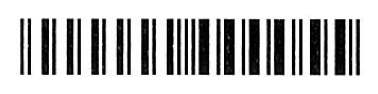

**Figura 6.10:** Decodificação de código de barras linear com *pyzbar*: imagem de entrada e dados extraídos.


Código de barras decodificado com sucesso [EAN13]:
0000000000055


In [70]:
import os
import numpy as np
from pyzbar.pyzbar import decode
from morph import mm

barcode_path = 'dados/barcode.png'

if os.path.exists(barcode_path):
    image = mm.read(barcode_path)
else:
    # Fallback sintético: gera um padrão de barras verticais que simula um Code-128
    print("[AVISO] Arquivo 'dados/barcode.png' não encontrado.")
    print("        Usando imagem sintética para demonstração do pipeline.")
    h, w = 100, 400
    img_synth = np.ones((h, w), dtype=np.uint8) * 255
    # Barras escuras em posições regulares (padrão simplificado)
    for x in range(20, w - 20, 8):
        if (x // 8) % 3 != 0:
            img_synth[:, x:x+4] = 0
    image = img_synth

mm.show(image)

barcodes = decode(image)

if barcodes:
    dados_bc = barcodes[0].data.decode("utf-8")
    tipo = barcodes[0].type
    print(f"Código de barras decodificado com sucesso [{tipo}]:\n{dados_bc}")
else:
    print("[INFO] Nenhum código de barras detectado na imagem.")
    print("Em imagem sintética isso é esperado — substitua pelo arquivo real para decodificar.")


### 6.10.2 O MCTest como estudo de caso: do protótipo ao sistema em produção

Até este ponto, cada etapa do *pipeline* foi implementada e analisada
isoladamente: correção da inclinação (*deskew*), detecção de marcadores,
retificação por perspectiva e leitura do *QRCode*. O **MCTest** integra
essas etapas em um sistema utilizado desde 2012 na UFABC para a correção
automatizada de avaliações de centenas de estudantes por semestre,
oferecendo suporte a diferentes modelos de folhas de resposta, gabaritos
individualizados e geração automática de relatórios de desempenho
(ZAMPIROLLI, 2023).

A partir deste ponto, o objetivo deixa de ser implementar novos algoritmos e
passa a ser compreender como eles são integrados em uma aplicação real,
atendendo a requisitos de robustez, manutenção e escalabilidade.

Desenvolvido na UFABC e disponibilizado como software de código aberto, o
MCTest será utilizado como estudo de caso. Nas próximas seções, será
analisado o módulo de Visão Computacional, implementado no arquivo
`CVMCTest.py`, destacando como os conceitos apresentados neste capítulo são
organizados em um sistema completo.

#### 6.10.2.1 Obtenção e Preparação do Módulo

O arquivo `CVMCTest.py` integra o sistema MCTest e depende de modelos e
configurações do *framework* Django, indisponíveis fora do ambiente Web.
Para utilizá-lo neste capítulo, o arquivo é obtido com `requests` e essas
dependências são removidas com `sed`, tornando o módulo autocontido.

In [71]:
import requests
CVMCTest = requests.get(
    "https://raw.githubusercontent.com/fzampirolli/mctest/master/exam/CVMCTest.py"
    )
with open('CVMCTest.py', 'w') as writefile:
    writefile.write(CVMCTest.text)

Cada comando `sed` remove importações específicas do ambiente Django,
tornando o arquivo `CVMCTest.py` utilizável de forma independente neste capítulo.

In [72]:
# remove linhas with "form django.", ...
!sed --in-place '/from django./d' CVMCTest.py
!sed --in-place '/from exam./d' CVMCTest.py
!sed --in-place '/from mctest./d' CVMCTest.py
!sed --in-place '/from student./d' CVMCTest.py
!sed --in-place '/from topic./d' CVMCTest.py
!sed --in-place '/from .models import VariationExam/d' CVMCTest.py

> ### 📝 6.11 🧠 Por que remover as dependências do Django?
>
> O arquivo `CVMCTest.py` foi desenvolvido para integrar uma aplicação Django
> e, por isso, importa modelos de banco de dados e configurações do sistema
> que não estão disponíveis neste capítulo. Essas dependências impedem a
> importação do módulo, embora não sejam necessárias para executar as rotinas
> de Visão Computacional.
>
> Os comandos `sed` removem apenas essas importações, preservando a lógica de
> processamento de imagens. Esse procedimento exemplifica uma prática comum de
> engenharia de software: desacoplar um módulo de sua infraestrutura para
> permitir sua reutilização em outros contextos.

#### 6.11.0.1 Extração da Área de Respostas

A função `getAnswerArea` encapsula as etapas de localização dos discos de
referência e retificação por perspectiva, retornando a região da folha que
contém os quadros de marcação, já alinhada e com dimensões fixas. A
[Figura 6.11](#fig-06-mctest-img-original) apresenta a imagem original em escala de cinza,
enquanto a [Figura 6.12](#fig-06-mctest-answer-area) mostra a área de respostas extraída.

[INGESTÃO] Página convertida: extra02.qrcode_p0.png
[INGESTÃO] Página convertida: extra02.qrcode_p1.png
[INGESTÃO] Página convertida: extra02.qrcode_p2.png


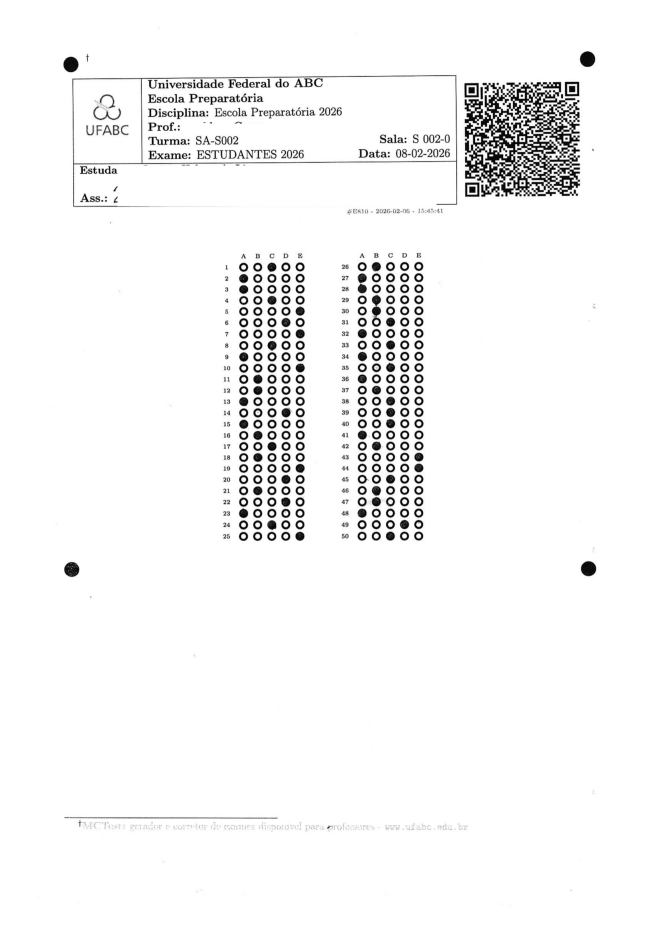

**Figura 6.11:** Imagem da folha de respostas em escala de cinza carregada a partir do PDF rasterizado.


In [73]:
import os
from pdf2image import convert_from_path
from skimage import data as skdata
import cv2
from morph import mm

file = "dados/provas_qrcode_EP.pdf"
MYFILES = 'extra02.qrcode'

if os.path.exists(file):
    pages = convert_from_path(file, 200)  # dpi 100=min 500=max
    numPAGES = 0
    for page in pages:
        myfile0 = MYFILES + '_p' + str(numPAGES) + '.png'
        page.save(myfile0)
        numPAGES += 1
        print(f"[INGESTÃO] Página convertida: {myfile0}")
    pages.clear()
    img_color = mm.read(myfile0)
    img_inicial = mm.gray(img_color)
else:
    print("[AVISO] Arquivo 'dados/provas_qrcode.pdf' não encontrado.")
    print("        Usando imagem pública skimage.data.page() como substituto.")
    img_inicial = skdata.page()

mm.show(img_inicial)


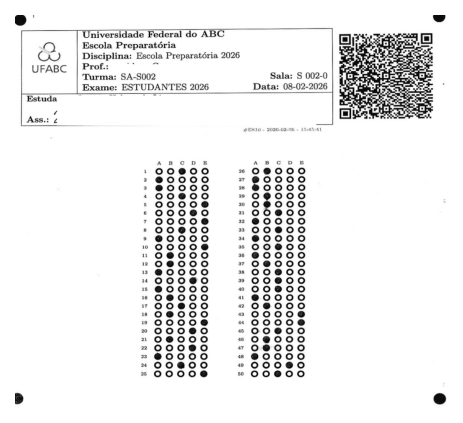

**Figura 6.12:** Área de respostas extraída por *getAnswerArea*: região retificada contendo os quadros de marcação.


In [74]:
import CVMCTest
countPage = 0
img_getAnswerArea = CVMCTest.cvMCTest.getAnswerArea(img_inicial, countPage)
mm.show(img_getAnswerArea)

**Nota de compatibilidade:** versões recentes do NumPy (≥ 2.0) removeram o alias `np.int0`. Caso `CVMCTest.py` utilize esse tipo, o comando abaixo aplica a correção diretamente no arquivo antes de recarregá-lo:

In [75]:
!sed -i 's/box = np.int0(cv2.boxPoints(rect))/box = cv2.boxPoints(rect).astype(np.intp)/' \
    ./CVMCTest.py

In [76]:
import importlib
import CVMCTest

importlib.reload(CVMCTest)

<module 'CVMCTest' from '/home/fz/fz/VSCode/pdi-vc/all/cap06/CVMCTest.py'>

#### 6.11.0.2 Segmentação do *QRCode* e Localização dos Quadros

Após a extração da área de respostas, o MCTest executa duas etapas
preparatórias para a leitura das bolhas: `segmentQRcode` e `findSquares`.

**Segmentação do *QRCode*.** A função `segmentQRcode` isola o *QRCode* para
uma tentativa de decodificação. Em seguida, `getQRCode` retorna o
indicador `myFlagArea`, que informa se a área de respostas foi localizada
corretamente, e o dicionário `qr`, utilizado para armazenar os metadados da
prova. Caso a decodificação não seja bem-sucedida, o processamento das
respostas é mantido, mas a identificação do aluno, obtida a partir do
*QRCode*, permanece em branco no arquivo CSV de saída. Dessa forma, todas as
folhas são processadas e registradas, uma por linha, mesmo quando o
*QRCode* não pode ser interpretado. A [Figura 6.13](#fig-06-mctest-qrcode-seg2) apresenta o
*QRCode* segmentado.

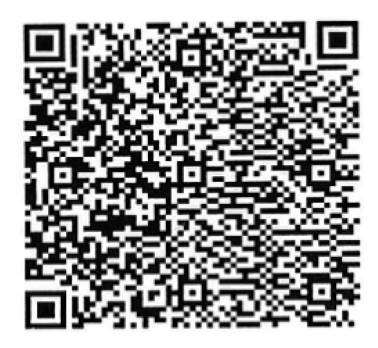

**Figura 6.13:** Região do *QRCode* isolada por *segmentQRcode* dentro da área de respostas retificada.


In [77]:
import CVMCTest
imgQRcode = CVMCTest.cvMCTest.segmentQRcode(img_getAnswerArea, countPage)
mm.show(imgQRcode)

A função `CVMCTest.cvMCTest.decodeQRcode(imgQRcode)` descriptografa a *string*
hexadecimal e retorna o dicionário `qr` com os metadados da prova,
apresentado na próxima seção.

##### Localização dos Quadros de Respostas

A área de respostas retornada por `getAnswerArea` engloba o cabeçalho da
folha, incluindo o *QRCode*, e os quadros de respostas posicionados logo
abaixo. Como apenas essa segunda região é utilizada na leitura das bolhas,
o recorte `img_getAnswerArea[300:, :]` isola a região de interesse
processada pela função `findSquares` para localizar os quadros de respostas.

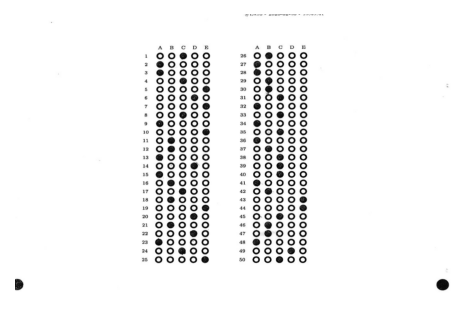

**Figura 6.14:** Recorte inferior da área de respostas, concentrando os quadros de bolhas a serem segmentados.


In [78]:
img_getAnswerArea_aux = img_getAnswerArea[300:,:]
mm.show(img_getAnswerArea_aux)

Os principais campos do dicionário `qr`, retornado pelo código a seguir, são:

* **`date`:** identificador temporal da prova, composto pela data de geração e um *timestamp* interno do MCTest.
* **`idClassroom`, `idExam`, `idStudent`:** identificadores da turma, da prova e do aluno, utilizados para localizar o gabarito e registrar os resultados.
* **`term`:** período letivo da prova.
* **`stylesheet`:** folha de estilo utilizada na geração do formulário, definindo seu *layout*.
* **`var1` a `var5`:** número de questões dos níveis de dificuldade 1 a 5, conforme a configuração da prova.
* **`text`:** número de questões dissertativas.
* **`answer`:** número de alternativas por questão.
* **`numquest`:** número total de questões da prova.
* **`correct`, `dbtext`:** campos preenchidos após a correção automática, contendo o gabarito e informações adicionais das questões.
* **`variations`, `variant`:** indicam a existência de variações da prova e a versão atribuída ao estudante.

Esses metadados permitem ao MCTest identificar a prova e o estudante,
recuperar o gabarito correspondente e configurar as etapas subsequentes de
leitura e correção das respostas. Na prática, a função
`CVMCTest.cvMCTest.decodeQRcode(imgQRcode)` é chamada internamente por
`CVMCTest.cvMCTest.getQRCode(img, countPage)`, apresentada na próxima seção,
que integra a segmentação e a decodificação do *QRCode* em uma única etapa
do *pipeline*.

In [79]:
myFlagArea, qr = CVMCTest.cvMCTest.getQRCode(img_inicial, countPage)
myFlagArea, qr

(True,
 {'date': '260208-1770403541363',
  'idClassroom': '955',
  'idExam': '810',
  'idStudent': '448898',
  'term': '0',
  'stylesheet': '1',
  'var1': '50',
  'var2': '0',
  'var3': '0',
  'var4': '0',
  'var5': '0',
  'text': '0',
  'answer': '5',
  'numquest': 50,
  'correct': '',
  'dbtext': '',
  'variations': '0',
  'variant': '0'})

In [80]:
rectSquares = CVMCTest.cvMCTest.findSquares(qr,img_getAnswerArea, countPage)
rectSquares

[[[np.int64(395), np.int64(350)], [np.int64(950), np.int64(516)]],
 [[np.int64(394), np.int64(602)], [np.int64(951), np.int64(767)]]]

#### 6.11.0.3 Leitura Automática das Respostas

As etapas desenvolvidas anteriormente são integradas no trecho de código a
seguir para processar cada quadro de respostas e compor as marcações do
estudante. Para cada quadro identificado em `rectSquares`, as funções
`setColumns` e `setLines` estimam, respectivamente, o número de alternativas
por questão e o número de questões, com base na distribuição espacial das
bolhas. Em seguida, `segmentAnswers` avalia o grau de preenchimento de cada
bolha e identifica a alternativa marcada. Por fim, `setAnswarsOneLine`
consolida as respostas de todos os quadros no campo `qr['answers']`,
produzindo uma única sequência de respostas. Quando o MCTest é utilizado de
forma independente, sem integração com seu banco de questões, essa sequência é
comparada ao gabarito presente na primeira página do PDF, que corresponde ao
modelo de prova sem enunciados adotado neste capítulo. A
[Figura fig-mctest-answers](#fig-mctest-answers) apresenta o conteúdo final de `qr['answers']`, contendo
as respostas lidas automaticamente.

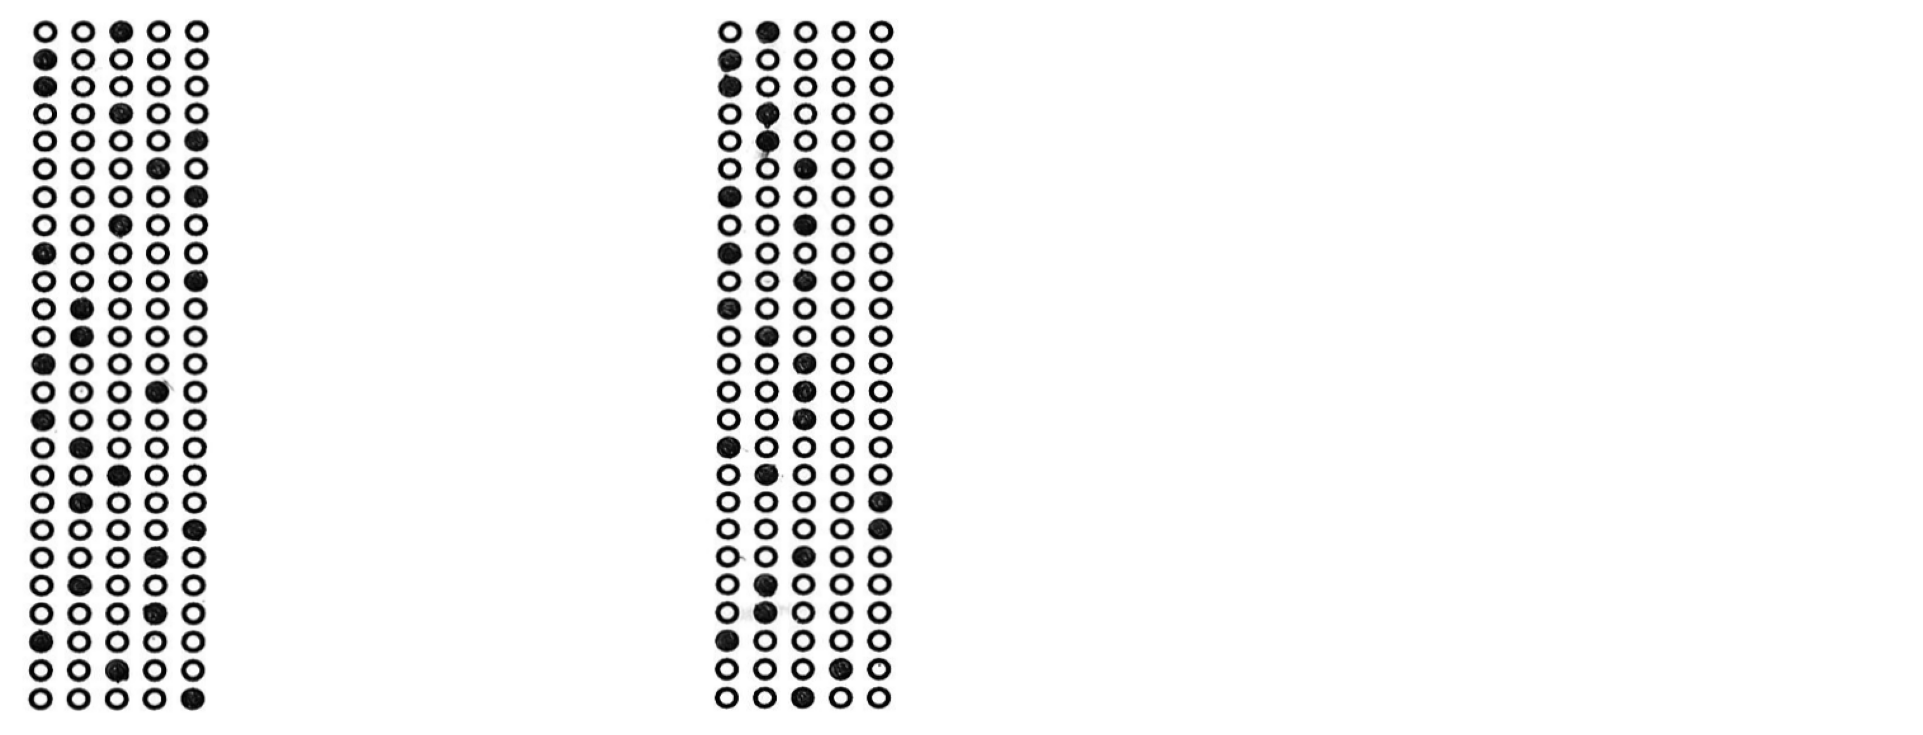

**Figura 6.15:** Respostas lidas automaticamente pelo MCTest após segmentação e classificação de todas as bolhas.


Respostas lidas das 50 questões:       
C,A,A,C,E,D,E,C,A,E,B,B,A,D,A,B,C,B,E,D,B,D,A,C,E,B,A,A,B,B,C,A,C,A,C,A,B,C,C,C,...


In [87]:
testAnswers = []
if myFlagArea:
  
  imgQ_all = []

  for countSquare in range(len(rectSquares)):
      p1, p2 = rectSquares[countSquare]

      if True:
          imgQi = CVMCTest.cvMCTest.imgAnswers[p1[0]:p2[0], p1[1]:p2[1]]
          [NUM_COLUMNS, img] = CVMCTest.cvMCTest.setColumns(imgQi, countPage, countSquare)
          [NUM_LINES, img] = CVMCTest.cvMCTest.setLines(imgQi, countPage, countSquare)
          NUM_RESPOSTAS = NUM_COLUMNS
          NUM_QUESTOES = NUM_LINES

      imgQiNC = CVMCTest.cvMCTest.imgAnswers[p1[0]:p2[0], p1[1]:p2[1]]
      testAnswers.append(CVMCTest.cvMCTest.segmentAnswers(
          [imgQi, imgQiNC], countPage, countSquare, NUM_QUESTOES, qr

      ))

      imgQ_all.append(imgQiNC)

  qr = CVMCTest.cvMCTest.setAnswarsOneLine(testAnswers, qr)  
  # deixa as respostas de cada quadro em uma linha

mm.show(imgQ_all)
print(f"Respostas lidas das {len(qr['answers'].split(","))} questões: \
      \n{qr['answers'][:-19]}...")

> ### 💡 6.12 Conectando os pontos
>
> O dicionário `qr['answers']` representa o resultado integrado das etapas
> desenvolvidas neste capítulo, desde a rasterização e a retificação
> geométrica até a decodificação do *QRCode* e a interpretação do
> preenchimento das bolhas.
>
> A principal diferença entre o protótipo implementado neste capítulo e o
> MCTest está na engenharia de software: tratamento de erros, suporte a
> múltiplos formatos, integração com banco de dados e interface Web. Os
> algoritmos de Visão Computacional permanecem essencialmente os mesmos.
>
> No modo de operação utilizado neste capítulo, a primeira página do PDF é
> assumida como gabarito, enquanto as páginas subsequentes correspondem às
> folhas de respostas dos estudantes. O MCTest compara automaticamente cada
> folha com esse gabarito para calcular a pontuação.

## 6.13 Inspeção Industrial Automatizada

A inspeção visual automatizada constitui uma importante aplicação da Visão
Computacional. Em sistemas de inspeção, câmeras capturam imagens de peças ou
produtos, que são analisadas por algoritmos para verificar critérios de
qualidade previamente definidos. Dependendo da aplicação, essa abordagem
pode reduzir a variabilidade da inspeção humana e aumentar a produtividade
do processo.

Neste capítulo são ilustradas duas estratégias clássicas para detecção de
defeitos:

- **Subtração de imagens:** compara a imagem capturada com uma referência
  livre de defeitos. Regiões cuja diferença de intensidade excede um limiar
  são classificadas como anomalias. Essa abordagem requer iluminação e
  posicionamento consistentes entre as imagens.

- **Análise de textura:** avalia a uniformidade local da superfície sem
  depender de uma imagem de referência. Pode ser aplicada a materiais
  homogêneos, como tecidos, papéis e metais, nos quais irregularidades
  locais podem indicar defeitos.

As duas abordagens são ilustradas a seguir com imagens sintéticas baseadas
em `skimage.data`, permitindo reproduzir os experimentos sem dependência de
bases de dados externas.

### 6.13.1 Referências e *Datasets* Públicos

Em aplicações reais, algoritmos de detecção de defeitos são frequentemente
avaliados em *datasets* públicos. Neste capítulo, utilizam-se imagens
sintéticas para garantir a reprodutibilidade dos exemplos, ver [Figura 6.16](#fig-06-industrial-defeito), mas os seguintes
conjuntos de dados podem ser empregados para experimentação e comparação de
algoritmos:

- **MVTec *Anomaly Detection Dataset* (MVTec AD):** reúne imagens de objetos e
  texturas com defeitos anotados em nível de pixel
  (BERGMANN et al., 2019). Disponível em:
  <https://www.mvtec.com/company/research/datasets/mvtec-ad>

- ***Kolektor Surface-Defect Dataset *(KolektorSDD):** contém imagens de
  componentes industriais com defeitos superficiais anotados
  (TABERNIK et al., 2020). Disponível em:
  <https://www.vicos.si/resources/kolektorsdd/>

- **NEU *Surface Defect Database*:** disponibiliza imagens de superfícies de
  aço laminado contendo seis categorias de defeitos
  (SONG; YAN, 2013). Disponível em:
  <http://faculty.neu.edu.cn/songkechen/zh_CN/zdylm/263270/list/index.htm>

> ### 📝 6.13.2 Subtração de Imagens e Registro Geométrico
>
> A subtração de imagens pressupõe que a imagem de inspeção esteja
> geometricamente alinhada à imagem de referência. Em aplicações reais,
> pequenas diferenças de posicionamento, rotação, escala ou perspectiva
> podem produzir diferenças maiores que o próprio defeito, gerando falsos
> positivos.
>
> Esse alinhamento é obtido por meio do **registro de imagens**, um processo
> que estima uma transformação geométrica capaz de fazer com que pontos
> correspondentes das duas imagens coincidam. Dependendo da aplicação, essa
> transformação pode corrigir apenas deslocamentos e rotações ou também
> variações de escala e perspectiva.
>
> Após o registro, a subtração tende a destacar apenas as diferenças
> causadas por defeitos, e não aquelas decorrentes da aquisição das imagens.

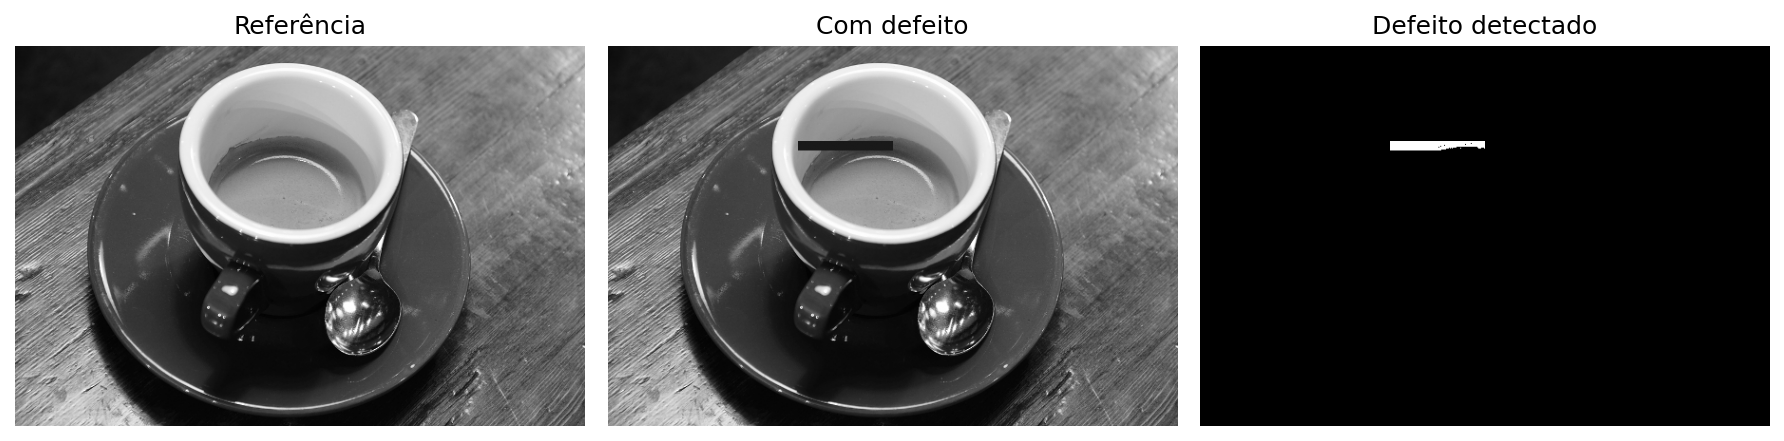

**Figura 6.16:** Detecção de defeito por subtração de imagem: produto de referência, imagem com defeito simulado e máscara de anomalia detectada.


Defeito detectado.


In [ ]:
import numpy as np
from skimage import data, color
from morph import mm

# Imagem de referência (produto sem defeito)
product_color = data.coffee()
product_gray = color.rgb2gray(product_color)

# Inserção de defeito simulado: arranhão escuro de 10×100 px
defect_image = np.copy(product_gray)
defect_image[100:110, 200:300] = 0.1

# Detecção por subtração e limiarização
difference = np.abs(product_gray - defect_image)
defect_threshold = 0.15          # ajustável conforme a aplicação
detected_defect = (difference > defect_threshold).astype(np.uint8) * 255

mm.show(
    [product_gray, defect_image, detected_defect],
    titles=["Referência", "Com defeito", "Defeito detectado"],
    cols=3,
    figsize=(12, 4)
)

status = "Defeito detectado." if detected_defect.any() else "Produto conforme."
print(status)

### 6.13.3 Detecção de Defeitos por Análise de Textura

Na ausência de uma imagem de referência, a inspeção pode explorar a
**homogeneidade local da textura**. Superfícies uniformes, como metais
polidos, tecidos e papéis, apresentam baixa variância local. Defeitos como
riscos, bolhas ou manchas aumentam essa variância em sua vizinhança,
permitindo sua detecção.

A [Figura 6.17](#fig-06-industrial-textura) ilustra essa abordagem com a imagem
`skimage.data.brick()`. Inicialmente, calcula-se a variância local em uma
janela deslizante; em seguida, o mapa resultante é limiarizado para destacar
as regiões heterogêneas.

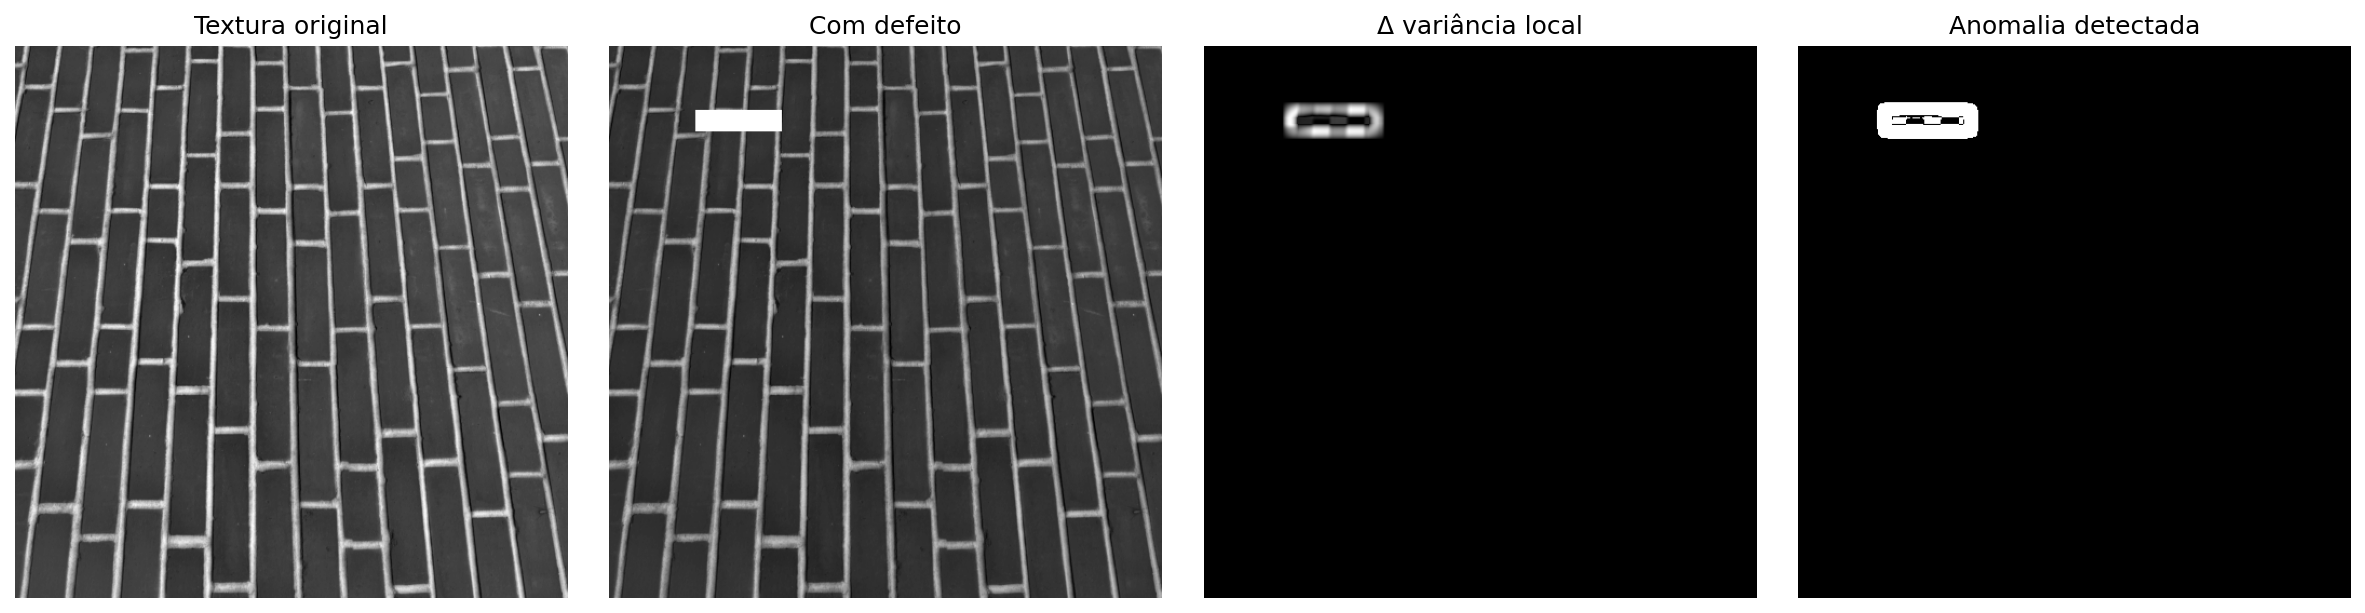

**Figura 6.17:** Detecção de heterogeneidade de textura: mapa de variância local e máscara de anomalia.


Defeito de textura detectado.


In [ ]:
import numpy as np
import cv2
from skimage import data as skdata
from morph import mm

# Imagem de textura uniforme (tijolo)
texture = skdata.brick().astype(np.float32) / 255.0

# Inserção de defeito sintético: mancha clara 20×80 px
texture_defect = np.copy(texture)
texture_defect[60:80, 80:160] = 0.95

# Mapa de variância local (janela 15×15)
def variancia_local(img, ksize=15):
    img_f = img.astype(np.float32)
    mean  = cv2.blur(img_f, (ksize, ksize))
    mean2 = cv2.blur(img_f ** 2, (ksize, ksize))
    return np.clip(mean2 - mean ** 2, 0, None)

var_ref    = variancia_local(texture)
var_defect = variancia_local(texture_defect)
diff_var   = np.abs(var_defect - var_ref)

# Normaliza e limiariza
diff_norm = (diff_var / diff_var.max() * 255).astype(np.uint8)
_, mask   = cv2.threshold(diff_norm, 30, 255, cv2.THRESH_BINARY)

mm.show(
    [texture, texture_defect, diff_norm, mask],
    titles=["Textura original", "Com defeito", "Δ variância local", "Anomalia detectada"],
    cols=4,
    figsize=(16, 4)
)

status = "Defeito de textura detectado." if mask.any() else "Superfície conforme."
print(status)


> ### 📝 6.14 🧠 Por que funciona? — Detecção de defeitos por subtração
>
> A subtração pixel a pixel entre a imagem de referência e a imagem
> capturada produz valores próximos de zero em regiões idênticas e valores
> elevados onde há diferenças. A operação `np.abs` torna o método
> insensível ao sinal da diferença, permitindo detectar tanto defeitos mais
> claros quanto mais escuros que a referência. Em seguida, a limiarização
> converte o mapa de diferenças em uma decisão binária: região conforme ou
> defeituosa.
>
> O principal parâmetro do método é o limiar (`defect_threshold`). Valores
> muito baixos tornam o algoritmo sensível ao ruído e aumentam a ocorrência
> de falsos positivos, enquanto valores muito altos podem impedir a detecção
> de defeitos sutis.

## 6.15 Resumo

Neste capítulo foram apresentadas técnicas de Visão Computacional aplicadas
à inspeção industrial e à análise automatizada de documentos.

* **Alinhamento de documentos (*deskew*):** a combinação entre detecção de
  bordas com Canny, estimação da orientação predominante pela Transformada de
  Hough e rotação inversa corrige automaticamente a inclinação de documentos
  digitalizados.
* **Normalização de fundo e CLAHE:** a divisão da imagem por uma versão
  suavizada cancela gradientes globais de iluminação; o CLAHE complementa
  esse processo equalizando o contraste localmente, tornando a limiarização
  por Otsu mais robusta em documentos com iluminação não uniforme.
* **Detecção de marcadores e retificação de perspectiva:** o fechamento
  morfológico com elemento estruturante grande isola os discos de referência;
  a filtragem por circularidade seleciona os quatro marcadores; a
  transformação de perspectiva retifica a folha para dimensões conhecidas.
* **Decodificação de *QRCode* e código de barras:** a abertura morfológica
  remove ruídos, a seleção pelo maior contorno quadrado isola o marcador e
  o redimensionamento por interpolação cúbica viabiliza a decodificação com
  `cv2.QRCodeDetector` e `pyzbar`.
* **Sistema MCTest:** integração das etapas anteriores em um *pipeline*
  completo de correção automatizada de avaliações, ilustrando a transição
  entre protótipo didático e sistema em produção.
* **Inspeção industrial:** detecção de defeitos por subtração de imagem de
  referência e por análise de variância local de textura, com exemplos
  sintéticos reprodutíveis e referência ao *dataset* MVTec AD.

O próximo capítulo aprofundará técnicas de **extração de características e
reconhecimento de padrões**, ampliando o escopo da Visão Computacional para
tarefas de classificação e reconhecimento de objetos.

## 6.16 🤖 Uso do NotebookLM como Tutor Complementar

Nesta edição, o uso do **NotebookLM** é incentivado como ferramenta
complementar de aprendizagem. Baseado em inteligência artificial, o sistema
utiliza exclusivamente os documentos fornecidos pelo autor como fonte de
conhecimento, produzindo respostas alinhadas ao conteúdo e à abordagem
adotada ao longo deste capítulo.

> ### ❗ 🎓 Estude com o Tutor Inteligente
>
> [🚀 ACESSAR NOTEBOOKLM: CAPÍTULO 06](https://notebooklm.google.com/)
>
> #### ⚠️ Aviso sobre Conteúdo Gerado por IA
>
> Embora seja uma ferramenta valiosa de apoio aos estudos, o NotebookLM pode
> eventualmente produzir respostas incompletas, imprecisas ou incorretas.
> Recomenda-se validar as informações consultando o material do capítulo,
> livros, artigos científicos e outras fontes acadêmicas confiáveis. Sempre
> que possível, execute e experimente os exemplos práticos apresentados ao
> longo do texto para consolidar a compreensão dos conceitos.

## 6.17 Exercícios Práticos

Os exercícios a seguir consolidam os conceitos apresentados neste capítulo,
propondo extensões do *pipeline* de processamento documental desenvolvido ao
longo do texto.

### 6.17.1 Exercício 1: Adaptação do *Pipeline* para Código de Barras

**Contexto:** O *pipeline* desenvolvido neste capítulo converte um PDF
em imagens, corrige a inclinação (*deskew*) e decodifica um *QRCode*.
Códigos de barras lineares (1D) também são amplamente empregados em
documentos institucionais, notas fiscais e etiquetas logísticas, seguindo um
fluxo de processamento bastante semelhante.

**Desafio:** Adapte esse *pipeline* para processar o arquivo
`dados/provas_barcode.pdf`, cujas páginas contêm códigos de barras lineares
no lugar de *QRCodes*. Para isso:

1. Rasterize o PDF com `pdf2image` utilizando resolução de 300 DPI;
2. Aplique a etapa de correção de inclinação (*deskew*) desenvolvida na seção anterior;
3. Utilize a biblioteca `pyzbar` (apresentada na próxima seção) para decodificar o código de barras;
4. Exiba a imagem retificada e a sequência de caracteres decodificada.

**Saída esperada:** A imagem retificada, seguida da string decodificada do
código de barras.

**Dica:** Ao contrário do *QRCode*, que é bidimensional, códigos de barras
lineares normalmente podem ser decodificados diretamente da imagem
rasterizada em 300 DPI, sem a necessidade de redimensionamento da região de
interesse.

### 6.17.2 Exercício 2: Validação Robusta da Leitura

**Contexto:** A detecção das bolhas utiliza critérios geométricos e de
preenchimento. Em imagens de baixa qualidade, ruídos e manchas podem gerar
falsos positivos.

**Desafio:**

1. Investigue critérios adicionais para validar as bolhas detectadas;
2. Avalie diferentes limiares de preenchimento;
3. Compare os resultados em imagens com diferentes níveis de ruído;
4. Discuta o impacto das escolhas na taxa de acertos e de falsos positivos.

**Saída esperada:** Uma tabela ou gráfico comparando o desempenho para
diferentes limiares e exemplos de detecções corretas e incorretas.

---

### 6.17.3 Exercício 3: Detecção de Marcação Inválida

**Contexto:** Em avaliações reais, uma questão pode apresentar dupla
marcação, rasuras ou ausência de resposta.

**Desafio:**

1. Detecte questões com duas ou mais alternativas preenchidas;
2. Identifique respostas em branco;
3. Defina um critério para sinalizar preenchimentos ambíguos;
4. Gere um relatório indicando o estado de cada questão.

**Saída esperada:** Um relatório em JSON ou `pandas.DataFrame` contendo,
para cada questão, a alternativa lida e seu estado (`OK`, `BRANCO`,
`DUPLA MARCAÇÃO` ou `SUSPEITA`).

---

### 6.17.4 Exercício 4: *Pipeline* Completo

**Contexto:** As etapas desenvolvidas neste capítulo podem ser integradas em
uma única aplicação.

**Desafio:**

1. Implemente uma função `processar_prova(caminho_pdf)` que:
   - converta o PDF em imagem;
   - retifique a folha;
   - decodifique o *QRCode*;
   - leia as respostas;
   - retorne os metadados e as respostas do estudante.

2. Avalie o *pipeline* em diferentes condições de aquisição (rotação,
resolução e qualidade de digitalização).

3. Documente as principais limitações observadas e proponha possíveis
melhorias.

**Saída esperada:** Um programa reutilizável acompanhado de exemplos de
execução em diferentes folhas de resposta.

---

## 6.18 Próximos Passos

Neste capítulo foi desenvolvido um *pipeline* completo para análise de
documentos, desde a conversão de PDFs em imagens até a leitura automática
de folhas de resposta por OMR. As técnicas estudadas — operações
morfológicas, transformações geométricas, análise de contornos e
decodificação de marcadores — constituem a base de diversos sistemas de
Visão Computacional.
Os próximos capítulos ampliam esse escopo para problemas mais gerais de
reconhecimento visual.

## Referências do Capítulo


BERGMANN, P. *et al*. **MVTec AD -- A Comprehensive Real-World Dataset for Unsupervised Anomaly Detection**. 2019.

SONG, K.; YAN, Y. **A Noise Robust Method Based on Completed Local Binary Patterns for Hot-Rolled Steel Strip Surface Defects**. 2013.

TABERNIK, D. *et al*. **Segmentation-Based Deep-Learning Approach for Surface-Defect Detection**. 2020.

ZAMPIROLLI, F. A. **MCTest: Como Criar e Corrigir Exames Parametrizados**. Independente, 2023.